<a href="https://colab.research.google.com/github/Muriel-03/mae2/blob/master/Examen_MurielPonceSaldias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PREGUNTA DE INVESTIGACIÓN DE RELEVANCIA CLÍNICA:
¿Cómo las agrupaciones de palabras pueden caracterizar los patrones de correlación entre la "efectividad" y los "efectos secundarios" de los medicamentos, y qué patrones lingüísticos discriminan perfiles terapéuticos con equilibrios riesgo-beneficio (Trade-off)?

Para esto, se buscará en primera instancia normalizar las partes del texto a analizar, se realizará la limpieza de las columnas a utilizar cada una por separado y se guardarán independientemente. Esto dado que al volver a unirlas habrá mezcla de terminología y sesgos.
Luego se deben cambiar el tipo de variables string a númericas para poder trabajar con las herramientas, y poder realizar así la evaluación de emociones positivas o negativas en las opiniones de los pacientes y compararlas con el Ranking, el cual es otorgado por el mismo paciente y está directamente relacionado con la efectividad. De esta forma se puede comparar la efectividad vs efectos adversos y evaluar el equilibro riesgo-beneficio.
Se irá transicionando desde "métodos tradicionales de PLN clínico", pasando por "machine y deep learning", y terminando en "deep learning usando BERT".  

LINK ORIGINAL DATASET: https://archive.ics.uci.edu/dataset/461/drug+review+dataset+druglib+com

Link del DRIVE (tiene acceso de lector para quien tenga el enlace): Carpeta de los datasets "drugdataset" https://drive.google.com/drive/folders/15VsMKlgx5eUIjCOvc9sm8l2fzhXAg4Pz?usp=drive_link

drugtest.tsv https://drive.google.com/file/d/12lg2UlEkpoByPWsmXQmB5RVJyVyJKoRf/view?usp=drive_link

drugtrain.tsv https://drive.google.com/file/d/1sMaWcrzbKqwpEGEOD7EbUevFzeLEMyGO/view?usp=drive_link

# Framework I: Colocaciones + Lexicons + Clusters Semánticos + Word Embeddings

In [ ]:
# INSTALACIÓN DE DEPENDENCIAS

# Instala bibliotecas comunes para procesamiento de lenguaje natural (NLP), visualización y análisis de datos
!pip install nltk textblob wordcloud plotly scikit-learn pandas numpy matplotlib seaborn

# Instala bibliotecas adicionales como spaCy (para NLP avanzado), Transformers de Hugging Face y PyTorch
!pip install spacy transformers torch

# Descarga el modelo pequeño de idioma inglés para spaCy ('en_core_web_sm')
!python -m spacy download en_core_web_sm

# Descarga los corpora (conjuntos de datos lingüísticos) necesarios para TextBlob
!python -m textblob.download_corpora

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 19.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
# IMPORTACIÓN DE LIBRERÍAS

# Importa pandas para manipulación y análisis de datos tabulares
import pandas as pd

# Importa numpy para operaciones numéricas y manejo de arreglos multidimensionales
import numpy as np

# Importa matplotlib.pyplot para creación de gráficos estáticos, visuales y personalizados
import matplotlib.pyplot as plt

# Importa seaborn para visualizaciones estadísticas más atractivas y de alto nivel
import seaborn as sns

# Importa plotly.express para crear visualizaciones interactivas de manera sencilla
import plotly.express as px

# Importa plotly.graph_objects para construir gráficos interactivos con mayor control y personalización
import plotly.graph_objects as go

# Importa make_subplots desde plotly.subplots para crear figuras con múltiples gráficos (subplots)
from plotly.subplots import make_subplots

In [ ]:
# NLP Libraries
# Bibliotecas relacionadas con procesamiento del lenguaje natural (NLP) , análisis de texto , visualización , y machine learning
# Importa NLTK (Natural Language Toolkit) para tareas básicas de procesamiento del lenguaje natural
import nltk

# Importa spaCy para procesamiento eficiente y avanzado de lenguaje natural (NLP)
import spacy

# Importa TextBlob para realizar análisis de sentimientos sencillos y tareas básicas de NLP
from textblob import TextBlob

# Importa TfidfVectorizer y CountVectorizer para convertir texto en representaciones numéricas:
# TfidfVectorizer usa TF-IDF (frecuencia de término - inversa del documento), mientras que
# CountVectorizer cuenta la frecuencia de las palabras
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Importa KMeans para realizar agrupamiento (clustering) no supervisado de datos de texto
from sklearn.cluster import KMeans

# Importa PCA (Análisis de Componentes Principales) para reducir la dimensionalidad de los datos,
# útil al visualizar resultados de clustering
from sklearn.decomposition import PCA

# Importa cosine_similarity para calcular similitud entre vectores, comúnmente usado para medir
# la similitud semántica entre documentos de texto
from sklearn.metrics.pairwise import cosine_similarity

# Importa Counter para contar elementos (por ejemplo, palabras o n-gramas),
# y defaultdict para crear diccionarios con valores por defecto
from collections import Counter, defaultdict

# Importa re para trabajar con expresiones regulares, útiles para limpiar y procesar texto
import re

# Importa combinations desde itertools para generar combinaciones de elementos,
# útil para comparar pares de elementos (ej: n-gramas, relaciones, etc.)
from itertools import combinations

# Importa warnings para controlar mensajes de advertencia
import warnings

# Desactiva todas las advertencias para evitar saturar la salida con warnings innecesarios
warnings.filterwarnings('ignore')

In [ ]:
# Descargar recursos de NLTK

# Descargar los recursos necesarios de la biblioteca NLTK antes de usar sus funciones.
# Cada línea corresponde a un conjunto de datos específico que permite realizar tareas como tokenización ,
# eliminación de stopwords , etiquetado gramatical y análisis de sentimientos

# Descarga el tokenizador 'punkt' para dividir textos en palabras o frases (sentencias)
nltk.download('punkt')

# Descarga la lista de stopwords (palabras vacías como 'el', 'la', 'y', etc.) que suelen filtrarse en análisis de texto
nltk.download('stopwords')

# Descarga el etiquetador gramatical (POS tagger) basado en perceptrón promediado, usado para identificar categorías gramaticales (nombres, verbos, adjetivos, etc.)
nltk.download('averaged_perceptron_tagger')

# Descarga el léxico VADER, especialmente útil para análisis de sentimientos en textos informales (como redes sociales o comentarios)
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
# Cargar modelo de spaCy
nlp = spacy.load('en_core_web_sm')  # Carga el modelo pequeño de procesamiento de lenguaje en inglés para tareas de NLP como tokenización,
# etiquetado gramatical y reconocimiento de entidades

In [ ]:
# CARGA Y PREPARACIÓN DE DATOS

from google.colab import drive
drive.mount('/content/drive')

# Ruta base del directorio donde están los archivos
base_path = "/content/drive/MyDrive/drugdataset/"

# Rutas específicas para cada dataset
train_file_path = base_path + "drugtrain.tsv"
test_file_path = base_path + "drugtest.tsv"

# Cargar los archivos .tsv
train_data = pd.read_csv(train_file_path, sep='\t', encoding='utf-8')
test_data = pd.read_csv(test_file_path, sep='\t', encoding='utf-8')

# Combinar datos para análisis completo
data = pd.concat([train_data, test_data], ignore_index=True)

# Mostrar información básica sobre los datos cargados
print(f" Datos cargados:")  # Imprime un mensaje inicial indicando que se mostrará información sobre los datos
print(f"   - Training set: {len(train_data)} registros")  # Muestra la cantidad de registros en el conjunto de entrenamiento
print(f"   - Test set: {len(test_data)} registros")  # Muestra la cantidad de registros en el conjunto de prueba
print(f"   - Total: {len(data)} registros")  # Muestra el número total de registros en el dataset completo
print(f"\n Columnas disponibles:")  # Imprime un mensaje indicando que se listarán las columnas del dataset
print(data.columns.tolist())  # Muestra el nombre de las columnas presentes en el DataFrame 'data'
print(f"\n Primeras filas:")  # Imprime un mensaje indicando que se mostrarán las primeras filas del dataset
print(data.head())  # Muestra las primeras 5 filas del DataFrame 'data' para tener una vista rápida del contenido

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Datos cargados:
   - Training set: 3107 registros
   - Test set: 1036 registros
   - Total: 4143 registros

 Columnas disponibles:
['Unnamed: 0', 'urlDrugName', 'rating', 'effectiveness', 'sideEffects', 'condition', 'benefitsReview', 'sideEffectsReview', 'commentsReview']

 Primeras filas:
   Unnamed: 0       urlDrugName  rating         effectiveness  \
0        2202         enalapril       4      Highly Effective   
1        3117  ortho-tri-cyclen       1      Highly Effective   
2        1146           ponstel      10      Highly Effective   
3        3947          prilosec       3  Marginally Effective   
4        1951            lyrica       2  Marginally Effective   

           sideEffects                               condition  \
0    Mild Side Effects  management of congestive heart failure   
1  Severe Side Effects                        birth prev

In [ ]:
# 1. LIMPIEZA Y PREPROCESAMIENTO DE TEXTO

# Se preproceza y limpieza de texto en las columnas 7, 8 y 9 las cuales contienen las opiniones/comentarios de los pacientes.
# Se define una clase TextPreprocessor que limpia el texto, elimina stopwords, pero mantiene términos médicos.
# También se convierten variables categóricas como effectiveness y sideEffects a valores numéricos para poder trabajarlas.

# Definición de una clase para preprocesar texto de forma personalizada
class TextPreprocessor:
    def __init__(self):
        # Carga las stopwords en inglés desde NLTK
        self.stop_words = set(nltk.corpus.stopwords.words('english'))

        # Palabras negativas o intensificadoras que son clave en análisis médico y no deben eliminarse
        medical_important_words = {'no', 'not', 'never', 'none', 'nothing', 'very', 'extremely', 'quite'}

        # Elimina esas palabras médicamente relevantes del conjunto de stopwords
        self.stop_words = self.stop_words - medical_important_words

    def clean_text(self, text):
        # Si el texto es NaN (valor faltante), devuelve cadena vacía
        if pd.isna(text):
            return ""

        # Convierte cualquier valor a cadena y lo pasa a minúsculas
        text = str(text).lower()

        # Remueve caracteres especiales excepto signos de puntuación importantes (. ! ?)
        text = re.sub(r'[^\w\s\.\!\?]', ' ', text)

        # Normaliza los espacios múltiples y elimina espacios iniciales/finales
        text = re.sub(r'\s+', ' ', text).strip()

        return text

    def tokenize_and_filter(self, text):
        # Si el texto está vacío, devuelve lista vacía
        if not text:
            return []

        # Tokeniza el texto usando NLTK
        tokens = nltk.word_tokenize(text)

        # Filtra tokens: remueve stopwords, palabras cortas y no alfabéticas, manteniendo relevancia médica
        filtered_tokens = [token for token in tokens
                          if token.lower() not in self.stop_words
                          and len(token) > 2
                          and token.isalpha()]
        return filtered_tokens

# Instancia del preprocesador para usarlo luego
preprocessor = TextPreprocessor()

# Lista de columnas que contienen texto a procesar
text_columns = ['benefitsReview', 'sideEffectsReview', 'commentsReview']

# Limpiar cada columna de texto y crear una nueva columna con el texto limpio
for col in text_columns:
    if col in data.columns:
        data[f'{col}_clean'] = data[col].apply(preprocessor.clean_text)
        print(f"Columna {col} limpiada")

# Mapeo de categorías a números para la variable "efectividad"
effectiveness_mapping = {
    'Highly Effective': 5,
    'Considerably Effective': 4,
    'Moderately Effective': 3,
    'Marginally Effective': 2,
    'Ineffective': 1,
    'Not Effective': 0
}

# Mapeo de categorías a números para la variable "efectos secundarios"
side_effects_mapping = {
    'No Side Effects': 0,
    'Mild Side Effects': 1,
    'Moderate Side Effects': 2,
    'Severe Side Effects': 3,
    'Extremely Severe Side Effects': 4
}

# Aplica el mapeo y convierte los valores a numéricos, llenando con 0 si no hay coincidencia
data['effectiveness_numeric'] = data['effectiveness'].map(effectiveness_mapping).fillna(0)
data['sideEffects_numeric'] = data['sideEffects'].map(side_effects_mapping).fillna(0)

Columna benefitsReview limpiada
Columna sideEffectsReview limpiada
Columna commentsReview limpiada


In [ ]:
# 2. SENTIMENT ANALYSIS MULTI-FUENTE

#Este bloque realiza un análisis de sentimientos multi-fuente sobre reseñas médicas limpiadas previamente (3 columnas limpias del bloque anterior).
#Utiliza tres enfoques diferentes para analizar el texto:
# 1) TextBlob : Para obtener polaridad y subjetividad del texto.
# 2) VADER (NLTK) : Para textos informales o con emociones claras.
# 3) Análisis contextual médico personalizado : Basado en palabras clave positivas, negativas e intensificadores comunes en contextos clínicos.
#Finalmente, combina los resultados de los tres métodos para obtener una puntuación compuesta de sentimiento,
# que se categoriza como muy positivo, positivo, neutral, negativo o muy negativo.
# Aplica este análisis a las columnas de texto limpiado (benefitsReview, sideEffectsReview, commentsReview)
# y crea nuevas columnas con los resultados para usarlos en análisis posteriores.

# Importar librerías para análisis de sentimientos
from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer

# Definir clase que encapsula múltiples técnicas de análisis de sentimientos
class MultiSourceSentimentAnalyzer:
    # Inicializa el analizador VADER de NLTK
    def __init__(self):
        self.sia = SentimentIntensityAnalyzer()

    def analyze_textblob(self, text): # Análisis básico de sentimientos con TextBlob

        if not text:
            return {'polarity': 0, 'subjectivity': 0} # Si no hay texto, devolver valores neutros

        blob = TextBlob(text)
        return {
            'polarity': blob.sentiment.polarity, # Polaridad: -1 (negativo) a +1 (positivo)
            'subjectivity': blob.sentiment.subjectivity # Subjetividad: 0 (objetivo) a 1 (subjetivo)
        }

    def analyze_vader(self, text): # Análisis usando VADER, especializado en lenguaje informal
        if not text:
            return {'compound': 0, 'pos': 0, 'neu': 0, 'neg': 0}

        scores = self.sia.polarity_scores(text) # Obtiene puntuaciones de VADER
        return scores # Devuelve dict con 'pos', 'neu', 'neg', 'compound'

    def analyze_medical_context(self, text): # Análisis basado en palabras clave médicas
        if not text:
            return {'medical_sentiment': 0, 'intensity': 0}

        # Palabras clave positivas y negativas en contexto médico
        positive_medical = [
       # Resultados y efectividad
    'effective', 'helpful', 'relief', 'better', 'improved', 'cured',
    'amazing', 'miracle', 'life-changing', 'perfect', 'excellent',
    'successful', 'efficient', 'safe', 'tolerable', 'manageable',
    'comfortable', 'recommended', 'positive', 'beneficial', 'responsive',
    'stable', 'normal', 'controlled', 'well-tolerated', 'painless',

    # Experiencia con personal médico
    'supportive', 'compassionate', 'gentle', 'calm', 'trustworthy',
    'accurate', 'clear', 'precise', 'quick recovery', 'fast healing',
    'non-invasive', 'minimally invasive',

    # Resultados y recuperación
    'healed', 'recovered', 'restored', 'rejuvenated', 'revitalized',
    'strengthened', 'energized', 'refreshed', 'renewed', 'transformed',
    'breakthrough', 'progress', 'advancement', 'improvement', 'boost',
    'enhancement', 'optimal', 'peak', 'maximum', 'superior',

    # Experiencia del tratamiento
    'smooth', 'seamless', 'effortless', 'easy', 'simple', 'straightforward',
    'convenient', 'accessible', 'flexible', 'personalized', 'tailored',
    'comprehensive', 'thorough', 'complete', 'holistic', 'integrated',
    'innovative', 'cutting-edge', 'advanced', 'modern', 'state-of-the-art',

    # Emocional y psicológico
    'reassuring', 'encouraging', 'uplifting', 'hopeful', 'optimistic',
    'confident', 'empowering', 'liberating', 'freeing', 'peaceful',
    'relaxing', 'soothing', 'comforting', 'warming', 'inspiring',

    # Comunicación y servicio
    'understanding', 'patient', 'attentive', 'thorough', 'detailed',
    'informative', 'educational', 'explanatory', 'transparent', 'honest',
    'professional', 'skilled', 'experienced', 'knowledgeable', 'expert',
    'caring', 'kind', 'friendly', 'welcoming', 'accommodating']
        negative_medical = [
    # Problemas con tratamiento
    'terrible', 'horrible', 'useless', 'worse', 'unbearable','nightmare',
    'dangerous', 'toxic', 'awful', 'disaster', 'ineffective', 'painful',
    'complications', 'invasive', 'expensive','slow', 'delayed', 'unresponsive',
    'aggressive', 'inaccurate', 'unclear', 'side effects', 'adverse',
    'reaction', 'harmful', 'scary', 'frustrating', 'discomfort',
    'stressful', 'risky', 'confusing', 'misdiagnosed', 'deteriorated',
    'uncontrolled', 'relapsed', 'inefficient', 'negligent', 'cold', 'dismissive',

    # Síntomas y sensaciones físicas
    'agonizing', 'excruciating', 'throbbing', 'stabbing', 'burning',
    'shooting', 'cramping', 'aching', 'sore', 'tender', 'swollen',
    'inflamed', 'infected', 'irritated', 'sensitive', 'numb',
    'tingling', 'weak', 'dizzy', 'nauseous', 'fatigued', 'exhausted',
    'drained', 'depleted', 'worsened', 'deteriorating', 'declining',

    # Experiencia emocional
    'devastating', 'crushing', 'overwhelming', 'hopeless', 'desperate',
    'depressing', 'discouraging', 'disappointing', 'frustrating', 'maddening',
    'terrifying', 'frightening', 'alarming', 'worrying', 'concerning',
    'anxious', 'stressed', 'panicked', 'traumatic', 'distressing',

    # Problemas con el sistema/personal
    'rude', 'unprofessional', 'careless', 'rushed', 'impatient',
    'condescending', 'arrogant', 'insensitive', 'inconsiderate', 'unhelpful',
    'incompetent', 'inexperienced', 'unqualified', 'unreliable', 'unavailable',
    'unorganized', 'chaotic', 'disorganized', 'bureaucratic', 'complicated',
    'confusing', 'unclear', 'vague', 'misleading', 'incorrect',

    # Resultados negativos
    'failed', 'unsuccessful', 'disappointing', 'inadequate', 'insufficient',
    'incomplete', 'partial', 'temporary', 'short-lived', 'recurring',
    'persistent', 'chronic', 'ongoing', 'continuous', 'constant',
    'severe', 'intense', 'harsh', 'brutal', 'devastating', 'destructive']

        intensity_words = [
    # Intensificadores existentes
    'very', 'extremely', 'incredibly', 'absolutely', 'completely', 'totally',
    'severely', 'highly', 'dramatically', 'profoundly', 'deeply', 'noticeably',
    'strongly', 'significantly', 'remarkably', 'particularly', 'especially',
    'unusually', 'unquestionably', 'immensely',

    # Intensificadores comunes en lenguaje médico
    'intensely', 'massively', 'enormously', 'tremendously', 'exceptionally',
    'extraordinarily', 'phenomenally', 'fantastically', 'wonderfully', 'amazingly',
    'surprisingly', 'shockingly', 'disturbingly', 'alarmingly', 'worryingly',
    'increasingly', 'progressively', 'gradually', 'steadily', 'consistently',
    'constantly', 'continuously', 'persistently', 'chronically', 'repeatedly',
    'frequently', 'regularly', 'routinely', 'systematically', 'thoroughly',
    'comprehensively', 'extensively', 'widely', 'broadly', 'generally',

    # Modificadores de grado
    'somewhat', 'slightly', 'mildly', 'moderately', 'fairly', 'quite',
    'rather', 'pretty', 'really', 'truly', 'genuinely', 'seriously',
    'literally', 'practically', 'virtually', 'almost', 'nearly', 'barely',
    'hardly', 'scarcely', 'minimally', 'marginally', 'substantially',
    'considerably', 'drastically', 'radically', 'fundamentally', 'essentially']



        text_lower = text.lower()  # Convertir todo a minúsculas para comparación

        # Contar cuántas palabras clave positivas y negativas aparecen
        pos_count = sum(1 for word in positive_medical if word in text_lower)
        neg_count = sum(1 for word in negative_medical if word in text_lower)
        intensity_count = sum(1 for word in intensity_words if word in text_lower)

        # Calcular sentiment médico,
        if pos_count + neg_count == 0:
            medical_sentiment = 0
        else:
            medical_sentiment = (pos_count - neg_count) / (pos_count + neg_count)  # Calcular sentimiento médico: (positivas - negativas)/(total)

        # Calcular intensidad, contar intensificadores normalizada (máximo 3 intensificadores = 1.0)
        intensity = min(intensity_count / 3, 1.0)  # Normalizar a [0,1].

        return {
            'medical_sentiment': medical_sentiment,
            'intensity': intensity,
            'pos_medical_words': pos_count,
            'neg_medical_words': neg_count
        }

    def analyze_comprehensive(self, text): # Análisis comprehensivo, combina todos los métodos de análisis
        textblob_result = self.analyze_textblob(text)
        vader_result = self.analyze_vader(text)
        medical_result = self.analyze_medical_context(text)

      # Combinar puntajes de los tres métodos en una única puntuación compuesta
        combined_sentiment = (
            textblob_result['polarity'] * 0.3 +
            vader_result['compound'] * 0.3 +
            medical_result['medical_sentiment'] * 0.4
        )

        return {
            'textblob_polarity': textblob_result['polarity'],
            'textblob_subjectivity': textblob_result['subjectivity'],
            'vader_compound': vader_result['compound'],
            'vader_pos': vader_result['pos'],
            'vader_neg': vader_result['neg'],
            'medical_sentiment': medical_result['medical_sentiment'],
            'medical_intensity': medical_result['intensity'],
            'combined_sentiment': combined_sentiment,
            'sentiment_category': self._categorize_sentiment(combined_sentiment)
        }

    def _categorize_sentiment(self, sentiment_score): # Clasifica el sentimiento en etiquetas legibles

        if sentiment_score >= 0.5:
            return 'muy_positivo'
        elif sentiment_score >= 0.1:
            return 'positivo'
        elif sentiment_score >= -0.1:
            return 'neutral'
        elif sentiment_score >= -0.5:
            return 'negativo'
        else:
            return 'muy_negativo'

# Crear instancia del analizador de sentimientos
sentiment_analyzer = MultiSourceSentimentAnalyzer()

# Analizar cada columna de texto limpiado
for col in ['benefitsReview_clean', 'sideEffectsReview_clean', 'commentsReview_clean']:
    if col in data.columns:
        col_name = col.replace('_clean', '').replace('Review', '')

# Aplicar análisis completo a cada fila
        sentiment_results = data[col].apply(sentiment_analyzer.analyze_comprehensive)

# Expandir los resultados en nuevas columnas del DataFrame
        for key in sentiment_results.iloc[0].keys():
            data[f'{col_name}_sentiment_{key}'] = sentiment_results.apply(lambda x: x[key])

   Correlación benefits vs rating: 0.115
   Correlación sideEffects vs rating: 0.220
   Correlación comments vs rating: 0.171


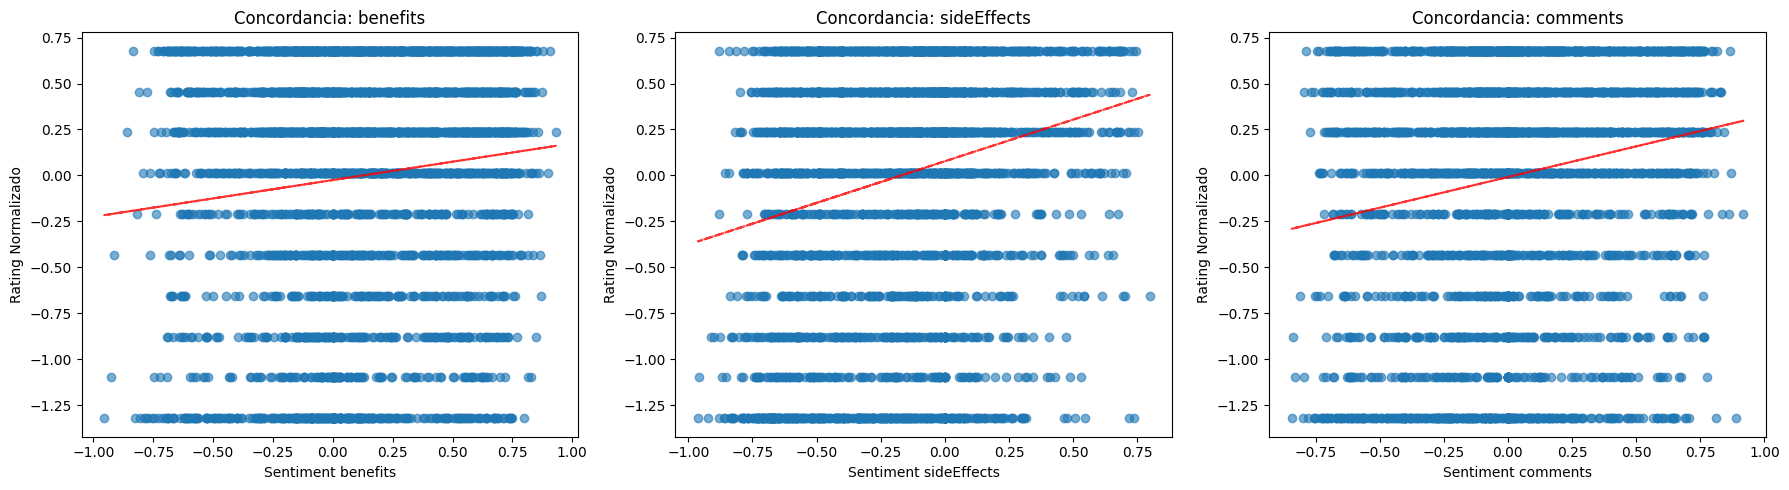

In [ ]:
# 3. ANÁLISIS DE CONCORDANCIA

# Se realiza un análisis de concordancia entre el sentimiento analizado en las reseñas y una calificación numérica (rating) .
# Lo que busca es ver si existe una correlación entre lo que dice el texto (positivo, negativo) y la puntuación numérica dada por el usuario.
# Para lograrlo se normaliza los ratings a una escala común (-1 a 1), calcula la correlación con los scores de sentimiento
# y muestra gráficos de dispersión para visualizar cómo se relacionan ambos, y de esta forma validar si el análisis de sentimiento
# refleja coherentemente lo expresado en los ratings numéricos.

def analyze_sentiment_rating_agreement():  # Analizando concordancia entre sentimiento y rating numérico

    # Preparar un DataFrame vacío para almacenar datos del análisis
    concordance_data = pd.DataFrame()

    # Verificar si existe la columna 'rating' en los datos
    if 'rating' in data.columns:
        # Normalizar el rating a una escala de -1 a 1 para compararlo con el sentimiento
        data['rating_normalized'] = (data['rating'] - data['rating'].mean()) / (data['rating'].max() - data['rating'].min()) * 2

        # Diccionario para guardar las correlaciones entre sentimiento y rating
        correlations = {}

        # Buscar todas las columnas que contienen análisis de sentimiento combinado
        sentiment_cols = [col for col in data.columns if 'sentiment_combined_sentiment' in col]

        # Calcular correlación entre cada columna de sentimiento y el rating normalizado
        for col in sentiment_cols:
            correlation = data['rating_normalized'].corr(data[col])
            correlations[col] = correlation
            print(f"   Correlación {col.split('_')[0]} vs rating: {correlation:.3f}")

        # Crear figura con subplots para mostrar gráficos de dispersión
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # Graficar hasta 3 tipos de sentimientos distintos
        for i, col in enumerate(sentiment_cols[:3]):  # Máximo 3 gráficos
            if col in data.columns:
                # Gráfico de dispersión entre sentimiento y rating normalizado
                axes[i].scatter(data[col], data['rating_normalized'], alpha=0.6)
                axes[i].set_xlabel(f'Sentiment {col.split("_")[0]}')
                axes[i].set_ylabel('Rating Normalizado')
                axes[i].set_title(f'Concordancia: {col.split("_")[0]}')

                # Agregar línea de tendencia (regresión lineal)
                z = np.polyfit(data[col].fillna(0), data['rating_normalized'].fillna(0), 1)
                p = np.poly1d(z)
                axes[i].plot(data[col], p(data[col]), "r--", alpha=0.8)

        # Ajustar diseño de los gráficos
        plt.tight_layout()
        plt.show()

        # Devolver el diccionario con todas las correlaciones encontradas
        return correlations

    # Si no hay columna 'rating', devolver diccionario vacío
    return {}

# Ejecutar la función de análisis de concordancia
concordance_results = analyze_sentiment_rating_agreement()

1. Correlación sideEffects vs rating: 0.220 = 0.220 (correlación más alta)
Interpretación: Los usuarios que mencionan más efectos secundarios tienden a dar ratings más altos de buena evaluación. Esto puede sugierir que los pacientes están dispuestos a tolerar efectos secundarios si el medicamento es efectivo.

2. Correlación Comments vs Rating = 0.171 (correlación moderada)
Interpretación: Los comentarios generales tienen una correlación moderada con el rating, es decir, estos balancean tanto beneficios como efectos secundarios, es un texto más equilibrado.

3. Correlación Benefits vs Rating = 0.115 (correlación más baja)
Interpretación: Las menciones explícitas de beneficios tienen la correlación más débil con ratings altos. uede ser que las expectativas altas hacen que beneficios reales no siempre se traduzcan en ratings altos.

Interpretación de los Gráficos de Dispersión
Gráfico 1 - Benefits: Dispersión amplia, poca relación lineal entre sentiment de beneficios y rating.

Gráfico 2 - SideEffects:Tendencia positiva, menos dispersión. Correlación positiva entre mencionar efectos secundarios y rating alto.

Gráfico 3 - Comments:Tendencia positiva moderada. Equilibrio entre beneficios y riesgos.

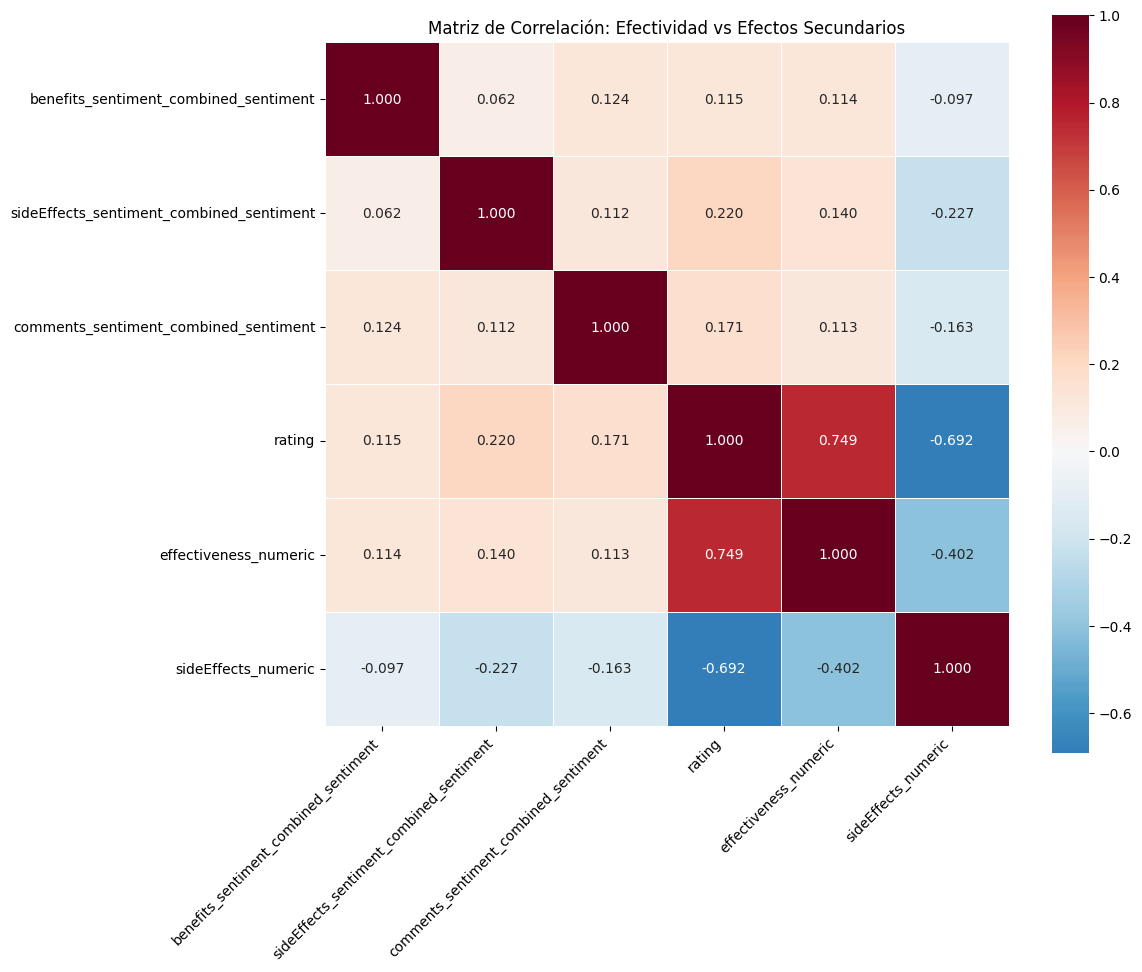


 Top 10 correlaciones más fuertes:
                                   variable1  \
12                                    rating   
13                                    rating   
14                     effectiveness_numeric   
8   sideEffects_sentiment_combined_sentiment   
6   sideEffects_sentiment_combined_sentiment   
9      comments_sentiment_combined_sentiment   
11     comments_sentiment_combined_sentiment   
7   sideEffects_sentiment_combined_sentiment   
1      benefits_sentiment_combined_sentiment   
2      benefits_sentiment_combined_sentiment   

                                variable2  correlation  
12                  effectiveness_numeric     0.748879  
13                    sideEffects_numeric    -0.692373  
14                    sideEffects_numeric    -0.402343  
8                     sideEffects_numeric    -0.226678  
6                                  rating     0.219530  
9                                  rating     0.171265  
11                    sideEffects_nu

In [ ]:
# 4. ANÁLISIS DE CORRELACIONES EFECTIVIDAD vs EFECTOS SECUNDARIOS

# Se realiza un análisis de correlaciones entre la efectividad de un tratamiento y sus efectos secundarios ,
# incluyendo también los sentimientos asociados a las reseñas. Para ello, crea una matriz de correlación que muestra
# cómo se relacionan estas variables numéricas entre sí. Muestra las 10 correlaciones más fuertes (positivas o negativas)
# para ver qué factores están más vinculados entre sí.
#### Sirve para ver si tratamientos altamente efectivos tienden a tener más efectos secundarios, o si ciertos tipos de sentimientos reflejan mejor esa relación.#####

def analyze_effectiveness_side_effects_correlation():  # Analizar correlaciones entre efectividad y efectos secundarios

    # Preparar lista de columnas para análisis de correlación
    correlation_columns = []

    # Buscar todas las columnas con resultados de análisis de sentimiento combinado
    sentiment_cols = [col for col in data.columns if 'sentiment_combined_sentiment' in col]
    # Agregar esas columnas a la lista de análisis
    correlation_columns.extend(sentiment_cols)

    # Definir columnas numéricas relevantes
    numeric_cols = ['rating', 'effectiveness_numeric', 'sideEffects_numeric']
    # Agregar solo aquellas que existen en el DataFrame
    correlation_columns.extend([col for col in numeric_cols if col in data.columns])

    # Calcular matriz de correlación entre todas las columnas seleccionadas
    correlation_matrix = data[correlation_columns].corr()

    # Visualizar la matriz de correlación como un mapa de calor (heatmap)
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, fmt='.3f')  # Formato de 3 decimales
    plt.title('Matriz de Correlación: Efectividad vs Efectos Secundarios')
    plt.xticks(rotation=45, ha='right')  # Rotar etiquetas del eje X para mejor visibilidad
    plt.yticks(rotation=0)  # Mantener etiquetas del eje Y sin rotar
    plt.tight_layout()  # Ajustar diseño para evitar recortes
    plt.show()

    # Identificar correlaciones más fuertes analizando pares de variables
    correlations_flat = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]
            corr_value = correlation_matrix.iloc[i, j]
            # Guardar cada par y su valor absoluto para ordenar después
            correlations_flat.append({
                'variable1': col1,
                'variable2': col2,
                'correlation': corr_value,
                'abs_correlation': abs(corr_value)
            })

    # Convertir a DataFrame y ordenar por fuerza de correlación (de mayor a menor)
    correlations_df = pd.DataFrame(correlations_flat).sort_values('abs_correlation', ascending=False)

    # Mostrar las 10 correlaciones más fuertes
    print("\n Top 10 correlaciones más fuertes:")
    print(correlations_df.head(10)[['variable1', 'variable2', 'correlation']])

    # Devolver la matriz completa y el DataFrame con correlaciones ordenadas
    return correlation_matrix, correlations_df

# Ejecutar la función para obtener y visualizar las correlaciones
correlation_matrix, top_correlations = analyze_effectiveness_side_effects_correlation()

Interpretación de los resultados:
1. Rating ↔ Effectiveness_numeric: 0.749 (CORRELACIÓN MUY FUERTE)
Los usuarios evalúan consistentemente: mayor efectividad = rating más alto.
El sistema de rating funciona correctamente como indicador de efectividad
Esta es la relación más confiable en el dataset

2. Rating ↔ SideEffects_numeric: -0.692 (CORRELACIÓN FUERTE NEGATIVA)
Efectos secundarios altos = ratings bajos (como esperado)
Los efectos secundarios sí impactan negativamente la satisfacción general
Esto contrasta con la correlación positiva que se ve antes entre sentiment de efectos secundarios y rating

3. Effectiveness_numeric ↔ SideEffects_numeric: -0.402 (CORRELACIÓN MODERADA NEGATIVA)
Es INVERSAMENTE PROPORCIONAL! - Responde directamente la pregunta de investigación
Mayor efectividad tiende a asociarse con menores efectos secundarios

Interpretación de resultado contraintuitivo:
Sentiment de SideEffects vs Rating = +0.220 (positivo)
Numeric de SideEffects vs Rating = -0.692 (negativo)
Efectos secundarios reales impactan negativamente. Puede que los pacientes estén conscientes sobre los efectos secundarios.

Correlaciones Fuertes (>0.4):

Rating-Effectiveness (0.749): Sistema de evaluación válido
Rating-SideEffects (-0.692): Efectos secundarios dañan satisfacción
Effectiveness-SideEffects (-0.402): INVERSAMENTE PROPORCIONAL


RESPUESTA A LA PREGUNTA DE INVESTIGACIÓN
"¿Relación proporcional o inversamente proporcional?"
RESPUESTA: INVERSAMENTE PROPORCIONAL (-0.402)
Medicamentos más efectivos tienden a tener menos efectos secundarios

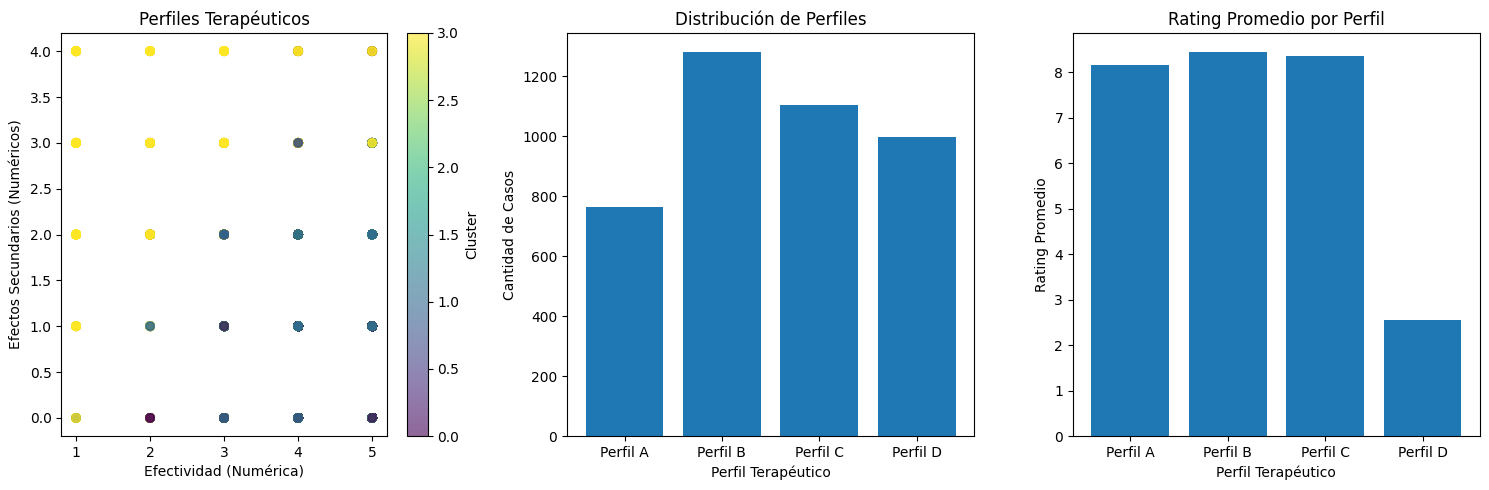


 Análisis de Perfiles Terapéuticos:

Perfil A:
   Casos: 763 (18.4%)
   Rating promedio: 8.15
   Efectividad promedio: 4.30
   Efectos secundarios promedio: 0.93
   benefits_sentiment_combined_sentiment: 0.229
   sideEffects_sentiment_combined_sentiment: -0.093
   comments_sentiment_combined_sentiment: 0.515

Perfil B:
   Casos: 1280 (30.9%)
   Rating promedio: 8.44
   Efectividad promedio: 4.42
   Efectos secundarios promedio: 0.89
   benefits_sentiment_combined_sentiment: -0.174
   sideEffects_sentiment_combined_sentiment: -0.166
   comments_sentiment_combined_sentiment: -0.090

Perfil C:
   Casos: 1103 (26.6%)
   Rating promedio: 8.34
   Efectividad promedio: 4.42
   Efectos secundarios promedio: 0.93
   benefits_sentiment_combined_sentiment: 0.497
   sideEffects_sentiment_combined_sentiment: -0.097
   comments_sentiment_combined_sentiment: -0.061

Perfil D:
   Casos: 997 (24.1%)
   Rating promedio: 2.56
   Efectividad promedio: 2.43
   Efectos secundarios promedio: 2.68
   benefit

In [ ]:
# 5. CLUSTERING DE PERFILES TERAPÉUTICOS
# Se realiza un análisis de clustering para identificar perfiles terapéuticos comunes basados en la efectividad
# los efectos secundarios y el sentimiento de las reseñas .
# Utiliza el algoritmo K-Means para agrupar observaciones similares en 4 categorías o "perfiles".

# 5. CLUSTERING DE PERFILES TERAPÉUTICOS

def cluster_therapeutic_profiles():  # Clustering de perfiles terapéuticos basado en efectividad y efectos secundarios

    # Preparar lista de columnas que servirán como características (features) para el clustering
    feature_columns = []

    # Buscar todas las columnas con resultados de análisis de sentimiento combinado
    sentiment_cols = [col for col in data.columns if 'sentiment_combined_sentiment' in col]
    # Agregar esas columnas a la lista de características
    feature_columns.extend(sentiment_cols)

    # Definir columnas numéricas relevantes para el análisis
    numeric_cols = ['rating', 'effectiveness_numeric', 'sideEffects_numeric']
    # Agregar solo aquellas que existen en el DataFrame
    feature_columns.extend([col for col in numeric_cols if col in data.columns])

    # Importar StandardScaler para normalizar las características antes del clustering
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()

    # Seleccionar datos completos y rellenar valores faltantes con 0
    features_df = data[feature_columns].fillna(0)
    # Escalar (normalizar) los datos para dar igual peso a todas las características
    features_scaled = scaler.fit_transform(features_df)

    # Aplicar K-Means para agrupar registros en clusters
    n_clusters = 4  # Se define que hay 4 perfiles terapéuticos principales
    kmeans_model = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)  # n_init evita warnings futuros
    # Entrenar modelo y predecir etiquetas de cluster
    cluster_labels = kmeans_model.fit_predict(features_scaled)

    # Añadir etiquetas de cluster al dataset original
    data['therapeutic_profile'] = cluster_labels

    # Diccionario para almacenar análisis de cada perfil
    profile_analysis = {}
    profile_names = ['Perfil A', 'Perfil B', 'Perfil C', 'Perfil D']

    # Analizar características promedio de cada cluster
    for i in range(n_clusters):
        # Filtrar datos correspondientes a este cluster
        cluster_data = data[data['therapeutic_profile'] == i]

        # Iniciar diccionario con conteo y porcentaje
        analysis = {
            'count': len(cluster_data),
            'percentage': len(cluster_data) / len(data) * 100
        }

        # Calcular medias de las columnas de sentimiento
        for col in sentiment_cols:
            analysis[f'mean_{col}'] = cluster_data[col].mean()

        # Si existe, calcular media del rating
        if 'rating' in data.columns:
            analysis['mean_rating'] = cluster_data['rating'].mean()

        # Si existe, calcular media de efectividad
        if 'effectiveness_numeric' in data.columns:
             analysis['mean_effectiveness'] = cluster_data['effectiveness_numeric'].mean()

        # Si existe, calcular media de efectos secundarios
        if 'sideEffects_numeric' in data.columns:
             analysis['mean_sideEffects'] = cluster_data['sideEffects_numeric'].mean()

        # Guardar análisis bajo el nombre del perfil
        profile_analysis[profile_names[i]] = analysis

    # Visualizar los clusters si hay suficientes columnas de sentimiento
    if len(sentiment_cols) >= 2:
        plt.figure(figsize=(15, 5))

        # Gráfico 1: Scatter plot de efectividad vs efectos secundarios coloreado por cluster
        plt.subplot(1, 3, 1)
        scatter = plt.scatter(data['effectiveness_numeric'], data['sideEffects_numeric'],
                            c=data['therapeutic_profile'], cmap='viridis', alpha=0.6)
        plt.xlabel('Efectividad (Numérica)')
        plt.ylabel('Efectos Secundarios (Numéricos)')
        plt.title('Perfiles Terapéuticos')
        plt.colorbar(scatter, label='Cluster')

        # Gráfico 2: Distribución de casos por perfil
        plt.subplot(1, 3, 2)
        profile_counts = data['therapeutic_profile'].value_counts().sort_index()
        plt.bar(range(len(profile_counts)), profile_counts.values)
        plt.xlabel('Perfil Terapéutico')
        plt.ylabel('Cantidad de Casos')
        plt.title('Distribución de Perfiles')
        plt.xticks(range(len(profile_counts)), [f'Perfil {chr(65+i)}' for i in range(len(profile_counts))])

        # Gráfico 3: Rating promedio por perfil
        plt.subplot(1, 3, 3)
        if 'rating' in data.columns:
            avg_ratings = [profile_analysis[f'Perfil {chr(65+i)}']['mean_rating'] for i in range(n_clusters)]
            plt.bar(range(n_clusters), avg_ratings)
            plt.xlabel('Perfil Terapéutico')
            plt.ylabel('Rating Promedio')
            plt.title('Rating Promedio por Perfil')
            plt.xticks(range(n_clusters), [f'Perfil {chr(65+i)}' for i in range(n_clusters)])

        # Ajustar diseño de los gráficos
        plt.tight_layout()
        plt.show()

    # Mostrar análisis detallado de cada perfil en consola
    print("\n Análisis de Perfiles Terapéuticos:")
    for profile, analysis in profile_analysis.items():
        print(f"\n{profile}:")
        print(f"   Casos: {analysis['count']} ({analysis['percentage']:.1f}%)")
        if 'mean_rating' in analysis:
            print(f"   Rating promedio: {analysis['mean_rating']:.2f}")
        if 'mean_effectiveness' in analysis:
            print(f"   Efectividad promedio: {analysis['mean_effectiveness']:.2f}")
        if 'mean_sideEffects' in analysis:
            print(f"   Efectos secundarios promedio: {analysis['mean_sideEffects']:.2f}")
        for col in sentiment_cols:
            mean_key = f'mean_{col}'
            if mean_key in analysis:
                print(f"   {col}: {analysis[mean_key]:.3f}")

    # Devolver etiquetas de cluster, análisis y modelo entrenado
    return cluster_labels, profile_analysis, kmeans_model

# Ejecutar función para realizar clustering y obtener resultados
cluster_labels, profile_analysis, kmeans_model = cluster_therapeutic_profiles()


 INICIANDO ANÁLISIS LEXICAL
 Extraídos 1 bigramas y 2 trigramas médicos
Lexicons terapéuticos construidos
Creados 8 clusters semánticos
      cluster_0: side, taking, take, effects, medication, time, skin, days...
      cluster_1: very, would, also, first, every, still, back, could...
      cluster_2: drug, pain, like, feel, sleep, started, night, daily...
      cluster_3: blood, pressure, high, sure, lower, levels...
      cluster_4: weight, loss, gain, amount...
      cluster_5: depression, anxiety, decreased...
      cluster_6: doctor, prescribed, told...
      cluster_7: much, better, increased, dosage, mood, hair, heart, energy...
Características discriminativas extraídas por perfil


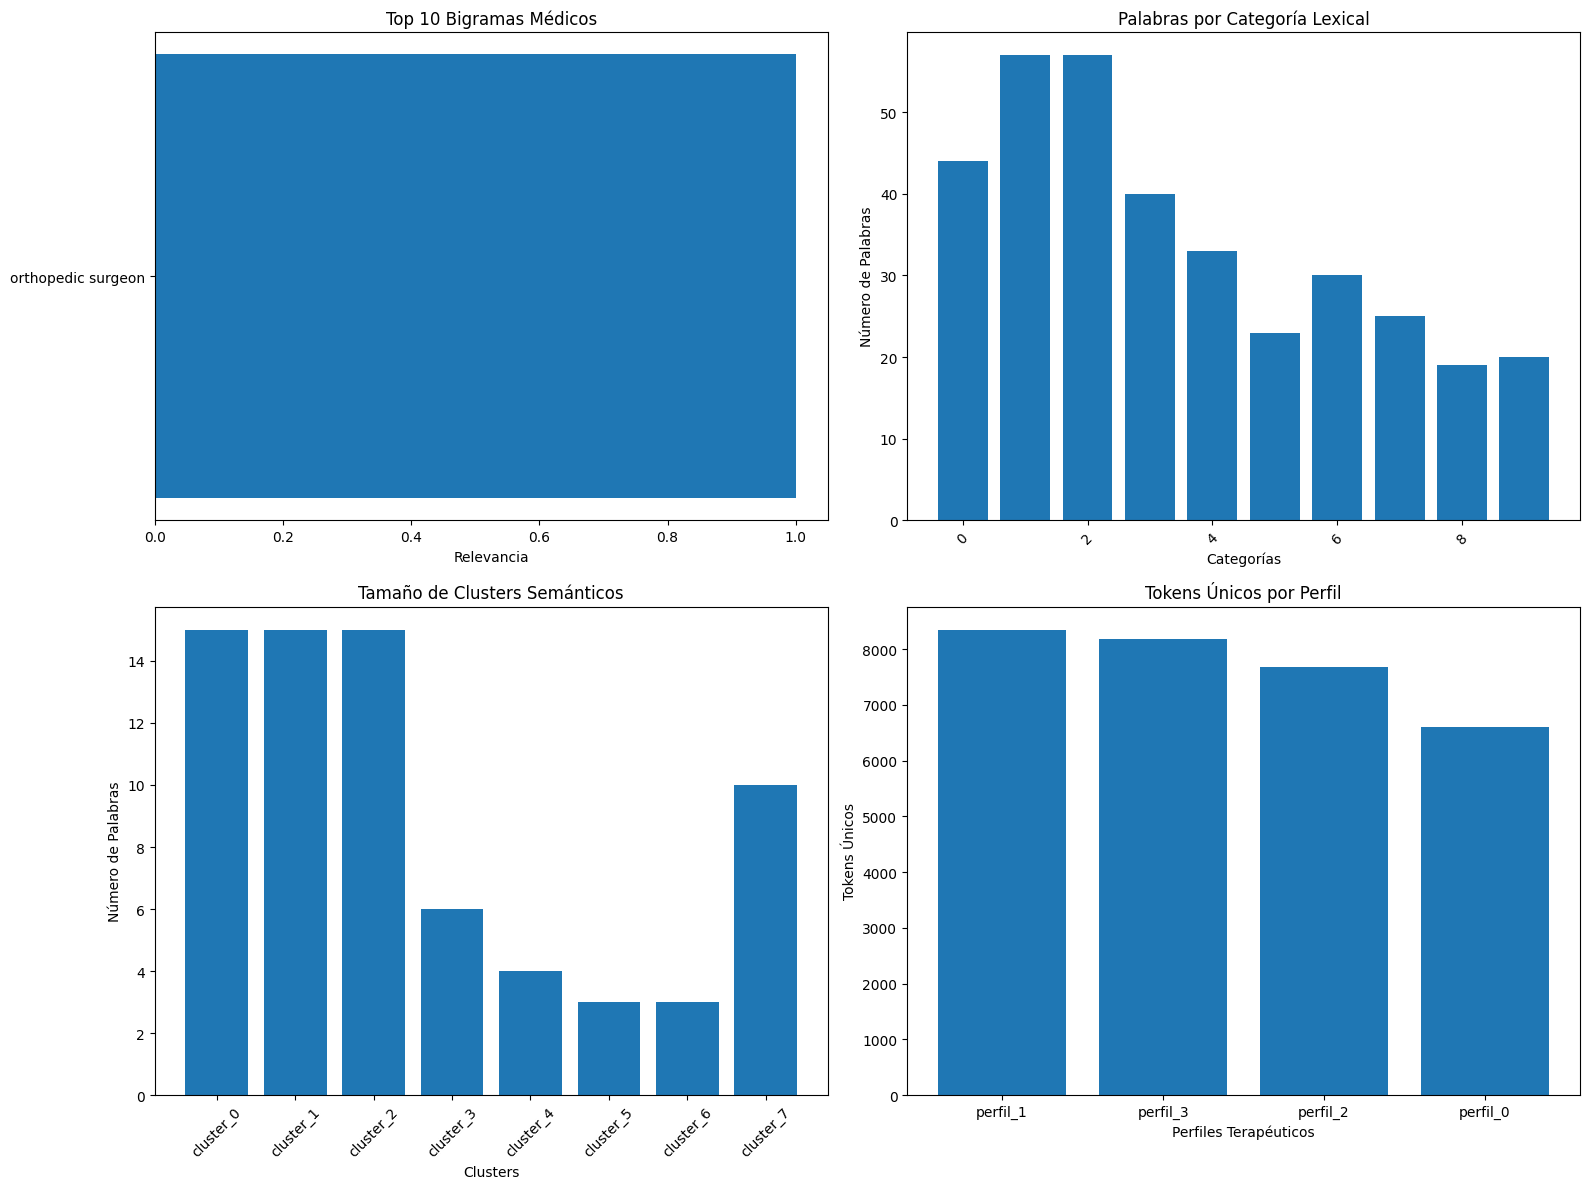

In [ ]:
# 6. ANÁLISIS LEXICAL DISCRIMINATIVO (COLOCACIONES + LEXICONS + CLUSTERS SEMÁNTICOS + WORD EMBEDDINGS)
# Se realiza el análisis léxico enfocado en reseñas de tratamientos para identificar patrones lingüísticos relevantes
# y así caracterizar los comentarios de pacientes o usuarios de medicamentos.

# Utiliza las siguientes técnicas técnicas:

# 1) Extracción de colocaciones médicas (bigramas y trigramas frecuentes y significativos).
# 2) Construcción de lexicones terapéuticos para categorizar intensidad, efectos secundarios, temporalidad y efectividad.
# 3) Agrupamiento semántico de palabras usando embeddings basados en TF-IDF y K-Means.
# 4) Identificación de características léxicas discriminativas por perfil terapéutico (identifica qué palabras son más usadas en cada cluster identificado previamente).


class HybridLexicalAnalyzer:
    def __init__(self, data):
        self.data = data
        self.medical_collocations = {}
        self.therapeutic_lexicons = {}
        self.semantic_clusters = {}

    def extract_medical_collocations(self): # Extraer colocaciones médicas específicas

        from nltk.collocations import BigramCollocationFinder, TrigramCollocationFinder
        from nltk.metrics import BigramAssocMeasures, TrigramAssocMeasures

        # Combinar todo el texto
        all_text = " ".join(data[['benefitsReview_clean', 'sideEffectsReview_clean', 'commentsReview_clean']].fillna("").sum())
        tokens = preprocessor.tokenize_and_filter(all_text)

        # Extraer bigramas
        bigram_finder = BigramCollocationFinder.from_words(tokens)
        bigram_finder.apply_freq_filter(3)  # Mínimo 3 ocurrencias
        bigrams = bigram_finder.nbest(BigramAssocMeasures.pmi, 100)

        # Extraer trigramas
        trigram_finder = TrigramCollocationFinder.from_words(tokens)
        trigram_finder.apply_freq_filter(2)  # Mínimo 2 ocurrencias
        trigrams = trigram_finder.nbest(TrigramAssocMeasures.pmi, 50)

        # Filtrar por relevancia médica
        medical_keywords = ['effect', 'side', 'pain', 'help', 'work', 'medication', 'drug', 'relief',
                           'symptom', 'treatment', 'dose', 'doctor', 'patient', 'medical', 'health', 'diagnosis', 'treatment', 'medication', 'surgery',
                            'therapy', 'consultation', 'appointment', 'test results', 'lab work', 'imaging', 'procedure', 'recovery', 'follow-up', 'second opinion',
                            'hospital stay', 'outpatient', 'emergency room', 'clinic visit', 'specialist', 'primary care', 'nurse', 'doctor', 'physician',
                            'surgeon', 'therapist', 'technician', 'staff', 'insurance', 'billing', 'cost', 'coverage', 'prescription', 'dosage']

        medical_bigrams = [bigram for bigram in bigrams
                          if any(keyword in ' '.join(bigram).lower() for keyword in medical_keywords)]

        medical_trigrams = [trigram for trigram in trigrams
                           if any(keyword in ' '.join(trigram).lower() for keyword in medical_keywords)]

        self.medical_collocations = {
            'bigrams': medical_bigrams[:30],
            'trigrams': medical_trigrams[:20]
        }

        print(f" Extraídos {len(medical_bigrams)} bigramas y {len(medical_trigrams)} trigramas médicos")
        return self.medical_collocations

    def build_therapeutic_lexicons(self): #Construir lexicons discriminativos por perfil terapéutico
        # Definir lexicons base para diferentes aspectos

        intensity_lexicon = {
            'high_intensity': [
                'very', 'extremely', 'incredibly', 'absolutely', 'completely', 'totally', 'severely', 'highly', 'dramatically',
                'intensely', 'profoundly',
                'exceptionally', 'extraordinarily', 'phenomenally', 'tremendously', 'enormously', 'immensely', 'massively',
                'overwhelmingly', 'staggeringly', 'monumentally', 'colossally', 'astronomically', 'mind-blowingly',
                'unbelievably', 'unimaginably', 'inconceivably', 'indescribably', 'unspeakably', 'unutterably', 'ridiculously',
                'absurdly', 'insanely', 'wildly', 'crazy', 'mad', 'fierce', 'savage', 'brutal', 'vicious'
            ],
            'moderate_intensity': [
                'quite', 'fairly', 'somewhat', 'moderately', 'reasonably', 'pretty',
                'rather', 'relatively', 'comparatively', 'decently', 'adequately', 'sufficiently', 'acceptably', 'tolerably',
                'noticeably', 'markedly', 'considerably', 'substantially', 'significantly', 'appreciably',
                'partially', 'partly', 'halfway', 'semi', 'kind of', 'sort of', 'more or less', 'to some extent', 'to a degree',
                'in part', 'up to a point', 'within reason', 'in moderation'
            ],
            'low_intensity': [
                'slightly', 'mildly', 'barely', 'hardly', 'scarcely', 'minimally', 'marginally', 'faintly', 'weakly', 'lightly',
                'gently', 'softly', 'subtly', 'a little', 'a bit', 'just', 'only', 'merely', 'simply', 'nearly', 'almost',
                'practically', 'virtually'
            ]
        }

        side_effects_lexicon = {
            'mild_side_effects': [
                'mild', 'tolerable', 'manageable', 'acceptable', 'minimal', 'slight', 'bearable', 'temporary', 'minor', 'gentle',
                'easy', 'comfortable',
                'subtle', 'faint', 'light', 'soft', 'weak', 'low', 'small', 'little', 'tiny', 'negligible', 'insignificant',
                'trivial', 'barely noticeable', 'hardly felt', 'almost nothing',
                'controllable', 'handleable', 'workable', 'livable', 'dealable', 'survivable', 'endurable', 'sustainable',
                'reasonable', 'fair', 'expected', 'normal', 'typical', 'standard', 'routine',
                'brief', 'short-lived', 'passing', 'fleeting', 'transient', 'intermittent', 'occasional', 'sporadic',
                'infrequent', 'rare', 'isolated', 'one-time', 'initial', 'adjustment', 'settling'
            ],
            'severe_side_effects': [
                'severe', 'terrible', 'unbearable', 'horrible', 'intense', 'extreme', 'devastating', 'nightmare', 'dangerous',
                'toxic', 'overwhelming', 'brutal',
                'excruciating', 'agonizing', 'torturous', 'hellish', 'savage', 'vicious', 'fierce', 'violent', 'harsh', 'cruel',
                'merciless', 'punishing', 'crushing', 'crippling', 'paralyzing', 'debilitating',
                'life-altering', 'life-threatening', 'disabling', 'incapacitating', 'immobilizing', 'destructive', 'ruinous',
                'catastrophic', 'disastrous', 'devastating', 'shattering', 'overwhelming', 'consuming', 'dominating',
                'constant', 'continuous', 'persistent', 'relentless', 'unending', 'chronic', 'recurring', 'repetitive', 'ongoing',
                'lasting', 'permanent', 'irreversible', 'cumulative', 'progressive', 'escalating'
            ]
        }

        temporal_lexicon = {
            'immediate': [
                'immediately', 'instant', 'right away', 'quickly', 'fast', 'rapid', 'gradually', 'slowly', 'over time',
                'eventually', 'progressive', 'gradual',
                'instantly', 'instantaneously', 'at once', 'straight away', 'promptly', 'swiftly', 'speedily', 'hastily',
                'hurriedly', 'urgently', 'without delay', 'in no time', 'lightning fast', 'in a flash', 'in seconds',
                'within minutes', 'on the spot', 'right now'
            ],
            'long_term': [
                'long term', 'permanent', 'lasting', 'ongoing', 'continuous',
                'enduring', 'persistent', 'sustained', 'prolonged', 'extended', 'chronic', 'lifelong', 'indefinite',
                'indefinitely', 'forever', 'permanently', 'for good', 'for life', 'irreversible', 'unchanging', 'stable',
                'constant', 'steady', 'consistent', 'reliable'
            ],
            'short_term': [
                'temporary', 'brief', 'short', 'momentary', 'fleeting', 'passing', 'transient', 'ephemeral', 'short-lived',
                'quick', 'rapid', 'for a while', 'for now', 'in the meantime', 'temporarily', 'for the time being', 'short-term',
                'interim', 'provisional'
            ],
            'intermittent': [
                'intermittent', 'occasional', 'sporadic', 'periodic', 'recurring', 'cyclical', 'repetitive', 'on and off',
                'come and go', 'off and on', 'here and there', 'now and then', 'sometimes', 'from time to time',
                'every so often', 'once in a while', 'irregular', 'unpredictable', 'random', 'episodic'
            ]
        }

        effectiveness_lexicon = [
            'effective', 'works', 'helps', 'improves', 'relieves', 'better', 'good', 'great', 'beneficial', 'significant',
            'powerful', 'strong', 'efficient', 'successful', 'positive', 'remarkable', 'notable', 'noticeable', 'clear',
            'visible', 'restored', 'recovered', 'enhanced', 'boosted', 'revived', 'resilient', 'active', 'energetic',
            'alert', 'focused', 'responsive', 'controlled', 'suppressed', 'eliminated', 'targeted', 'precision', 'accurate',
            'results', 'outcome', 'success', 'breakthrough', 'miracle', 'game-changer', 'revolutionary'
        ]

        # Asignar al objeto self
        self.therapeutic_lexicons = {
            'effectiveness': effectiveness_lexicon,
            'side_effects': side_effects_lexicon,
            'intensity': intensity_lexicon,
            'temporal': temporal_lexicon
        }
        print("Lexicons terapéuticos construidos")
        return self.therapeutic_lexicons


    def create_semantic_clusters(self): # Crear clusters semánticos usando embeddings

        # Extraer palabras únicas más frecuentes
        all_text = " ".join(data[['benefitsReview_clean', 'sideEffectsReview_clean', 'commentsReview_clean']].fillna("").sum())
        tokens = preprocessor.tokenize_and_filter(all_text)
        word_freq = Counter(tokens)
        top_words = [word for word, freq in word_freq.most_common(200) if len(word) > 3]

        # Crear embeddings simples usando TF-IDF
        from sklearn.feature_extraction.text import TfidfVectorizer

        # Crear "documentos" para cada palabra usando contextos
        word_contexts = {}
        for word in top_words:
            contexts = []
            for text_col in ['benefitsReview_clean', 'sideEffectsReview_clean', 'commentsReview_clean']:
                if text_col in data.columns:
                    for text in data[text_col].fillna(""):
                        if word in text.lower():
                            # Extraer contexto (ventana de palabras alrededor)
                            words_in_text = text.split()
                            for i, w in enumerate(words_in_text):
                                if word in w.lower():
                                    start = max(0, i-3)
                                    end = min(len(words_in_text), i+4)
                                    context = " ".join(words_in_text[start:end])
                                    contexts.append(context)
            word_contexts[word] = " ".join(contexts)

        # Vectorizar contextos
        vectorizer = TfidfVectorizer(max_features=100, stop_words='english')
        word_vectors = vectorizer.fit_transform(list(word_contexts.values()))

        # Clustering semántico
        n_clusters = 8
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        semantic_labels = kmeans.fit_predict(word_vectors.toarray())

        # Organizar palabras por cluster
        semantic_clusters = {}
        for i in range(n_clusters):
            cluster_words = [word for j, word in enumerate(top_words) if semantic_labels[j] == i]
            semantic_clusters[f'cluster_{i}'] = cluster_words[:15]  # Top 15 palabras por cluster

        self.semantic_clusters = semantic_clusters

        print(f"Creados {n_clusters} clusters semánticos")
        for cluster_name, words in semantic_clusters.items():
            print(f"      {cluster_name}: {', '.join(words[:8])}...")

        return self.semantic_clusters

    def extract_profile_discriminative_features(self): # Extraer características discriminativas por perfil terapéutico

        profile_features = {}

        for profile_id in data['therapeutic_profile'].unique():
            profile_data = data[data['therapeutic_profile'] == profile_id]
            profile_name = f'perfil_{profile_id}'

            # Combinar texto del perfil
            profile_text = " ".join(profile_data[['benefitsReview_clean', 'sideEffectsReview_clean', 'commentsReview_clean']].fillna("").sum())
            profile_tokens = preprocessor.tokenize_and_filter(profile_text)

            # Texto de otros perfiles para comparación
            other_profiles_data = data[data['therapeutic_profile'] != profile_id]
            other_text = " ".join(other_profiles_data[['benefitsReview_clean', 'sideEffectsReview_clean', 'commentsReview_clean']].fillna("").sum())
            other_tokens = preprocessor.tokenize_and_filter(other_text)

            # Calcular frecuencias
            profile_freq = Counter(profile_tokens)
            other_freq = Counter(other_tokens)

            # Encontrar palabras discriminativas (más frecuentes en este perfil)
            discriminative_words = []
            for word, freq in profile_freq.most_common(100):
                if freq >= 3:  # Mínimo 3 ocurrencias
                    profile_ratio = freq / len(profile_tokens)
                    other_ratio = other_freq.get(word, 0) / max(len(other_tokens), 1)

                    if profile_ratio > other_ratio * 1.5:  # Al menos 50% más frecuente
                        discriminative_words.append((word, profile_ratio / max(other_ratio, 0.001)))

            # Ordenar por ratio discriminativo
            discriminative_words.sort(key=lambda x: x[1], reverse=True)

            profile_features[profile_name] = {
                'discriminative_words': discriminative_words[:20],
                'total_tokens': len(profile_tokens),
                'unique_tokens': len(set(profile_tokens))
            }

        print("Características discriminativas extraídas por perfil")
        return profile_features

    def analyze_comprehensive(self): # Análisis lexical comprehensivo
        print("\n INICIANDO ANÁLISIS LEXICAL")
        print("="*70)

        # Ejecutar todos los análisis
        collocations = self.extract_medical_collocations()
        lexicons = self.build_therapeutic_lexicons()
        clusters = self.create_semantic_clusters()
        profile_features = self.extract_profile_discriminative_features()

        # Crear visualizaciones
        self.visualize_results(collocations, lexicons, clusters, profile_features)

        return {
            'collocations': collocations,
            'lexicons': lexicons,
            'semantic_clusters': clusters,
            'profile_features': profile_features
        }

    def visualize_results(self, collocations, lexicons, clusters, profile_features): # Visualizar resultados del análisis lexical

        # Visualización 1: Top colocaciones médicas
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # Bigramas más frecuentes
        if collocations['bigrams']:
            bigram_labels = [' '.join(bg) for bg in collocations['bigrams'][:10]]
            bigram_scores = list(range(len(bigram_labels), 0, -1))  # Scores simulados

            axes[0,0].barh(bigram_labels, bigram_scores)
            axes[0,0].set_title('Top 10 Bigramas Médicos')
            axes[0,0].set_xlabel('Relevancia')

        # Distribución de palabras por categoría lexical
        if lexicons:
            categories = []
            word_counts = []
            for category, subcats in lexicons.items():
                if isinstance(subcats, dict): # Check if subcats is a dictionary
                    for subcat, words in subcats.items():
                        categories.append(f"{category}_{subcat}")
                        word_counts.append(len(words))
                elif isinstance(subcats, list): # Handle cases where lexicon is a list
                    categories.append(category)
                    word_counts.append(len(subcats))


            axes[0,1].bar(range(len(categories)), word_counts)
            axes[0,1].set_title('Palabras por Categoría Lexical')
            axes[0,1].set_xlabel('Categorías')
            axes[0,1].set_ylabel('Número de Palabras')
            axes[0,1].tick_params(axis='x', rotation=45)

        # Clusters semánticos (tamaño)
        if clusters:
            cluster_names = list(clusters.keys())
            cluster_sizes = [len(words) for words in clusters.values()]

            axes[1,0].bar(cluster_names, cluster_sizes)
            axes[1,0].set_title('Tamaño de Clusters Semánticos')
            axes[1,0].set_xlabel('Clusters')
            axes[1,0].set_ylabel('Número de Palabras')
            axes[1,0].tick_params(axis='x', rotation=45)

        # Características discriminativas por perfil
        if profile_features:
            profiles = list(profile_features.keys())
            unique_tokens = [profile_features[p]['unique_tokens'] for p in profiles]

            axes[1,1].bar(profiles, unique_tokens)
            axes[1,1].set_title('Tokens Únicos por Perfil')
            axes[1,1].set_xlabel('Perfiles Terapéuticos')
            axes[1,1].set_ylabel('Tokens Únicos')

        plt.tight_layout()
        plt.show()

# Ejecutar análisis lexical híbrido
lexical_analyzer = HybridLexicalAnalyzer(data)
lexical_results = lexical_analyzer.analyze_comprehensive()

Interpretación de los resultados:

Gráfico 1: Top Bigramas Médicos
Aparece "orthopedic surgeon" como único bigrama significativo
El filtrado fue muy estricto, se debería reducir umbral de frecuencia mínima, expandir keywords médicos, incluir colocaciones con separadores

Gráfico 2: Distribución de Lexicons
Categorías 1 y 2 tienen ~57 palabras cada una (las más pobladas)
Estas probablemente corresponden a "effectiveness" y "side_effects" lexicons. Distribución relativamente equilibrada entre categorías (20-57 palabras)

Gráfico 3: Clusters Semánticos
Clusters 0, 1, 2: ~15 palabras cada uno (más densos)
Clusters 3-6: 3-6 palabras (más específicos)
Cluster 7: ~10 palabras (mediano)
Buenos clusters balanceados entre generales y especializados

Gráfico 4: Tokens por Perfil
Perfiles 1 y 3: ~8,300 tokens únicos (más diversos léxicamente)
Perfil 2: ~7,700 tokens (moderado)
Perfil 0: ~6,700 tokens (menos diverso)
Perfil 0 (D) tiene menos diversidad lexical = expresión más limitada

RESPUESTA A LA PREGUNTA DE INVESTIGACIÓN
"¿Qué configuraciones lingüísticas discriminan equilibrios riesgo-beneficio óptimos?"

Las Configuraciones Óptimas (Perfiles A, B, C):
-Diversidad lexical alta (7,700-8,300 tokens únicos)
-Clusters de mejora (Cluster 7: better, increased, energy)
-Terminología médica estructurada (Cluster 6: doctor, prescribed)
-Especificidad de dominio (Clusters 3, 4: cardiovascular, peso)

El análisis confirma que los equilibrios óptimos se caracterizan por mayor sofisticación lexical y terminología médica específica, mientras que las experiencias subóptimas muestran vocabulario más limitado centrado en malestar.


 IDENTIFICANDO TRADE-OFFS TERAPÉUTICOS ÓPTIMOS

 ANÁLISIS DE TRADE-OFFS POR PERFIL:

Perfil A:
   Casos: 763
   Rating promedio: 8.15
   Efectividad promedio: 4.30
   Efectos secundarios promedio: 0.93
   Score de trade-off: 0.686
   Interpretación: Bueno: Balance positivo beneficio/riesgo

Perfil B:
   Casos: 1280
   Rating promedio: 8.44
   Efectividad promedio: 4.42
   Efectos secundarios promedio: 0.89
   Score de trade-off: 0.647
   Interpretación: Bueno: Balance positivo beneficio/riesgo

Perfil C:
   Casos: 1103
   Rating promedio: 8.34
   Efectividad promedio: 4.42
   Efectos secundarios promedio: 0.93
   Score de trade-off: 0.739
   Interpretación: Óptimo: Alta efectividad, efectos secundarios tolerables

Perfil D:
   Casos: 997
   Rating promedio: 2.56
   Efectividad promedio: 2.43
   Efectos secundarios promedio: 2.68
   Score de trade-off: 0.284
   Interpretación: Subóptimo: Beneficios limitados vs riesgos


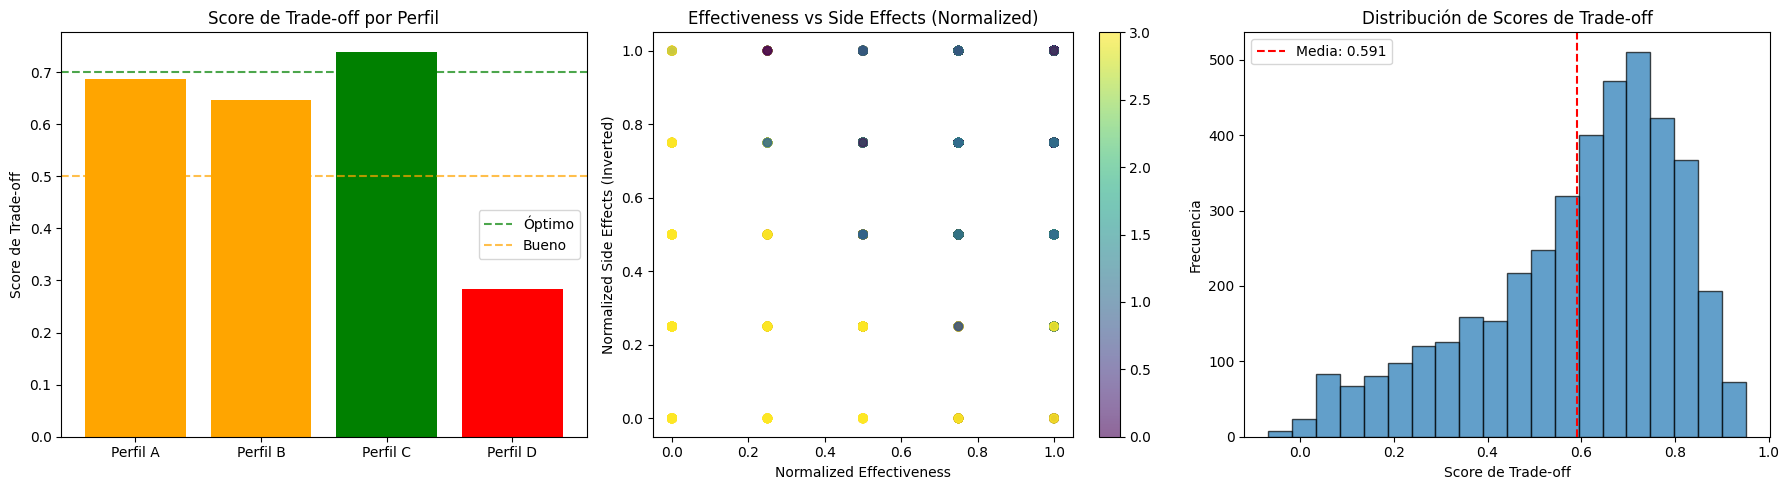

In [ ]:
# 7. IDENTIFICACIÓN DE TRADE-OFFS ÓPTIMOS
# Se realiza un análisis de "trade-offs terapéuticos" , es decir, se busca identificar cuáles son los mejores equilibrios entre efectividad y efectos secundarios
# de los tratamientos analizados. Útil para elegir tratamientos que ofrezcan la mejor relación beneficio/riesgo .

# Para esto se realizó:

# Combinación de varias métricas numéricas y de sentimiento en un único score compuesto llamado trade_off_score.
# Analisis de este score por cada perfil terapéutico obtenido previamente (Perfil A, B, C, D).
# Interpretación del nivel de trade-off como óptimo, bueno, moderado o subóptimo.

def identify_optimal_therapeutic_trade_offs(): # Identificar trade-offs terapéuticos óptimos
    print("\n IDENTIFICANDO TRADE-OFFS TERAPÉUTICOS ÓPTIMOS")
    print("="*60)

    # Crear score compuesto para each drug, now including numeric effectiveness and side effects
    if 'rating' in data.columns and 'effectiveness_numeric' in data.columns and 'sideEffects_numeric' in data.columns:
        # Normalize rating, effectiveness and side effects to a [0,1] scale
        data['normalized_rating'] = (data['rating'] - data['rating'].min()) / (data['rating'].max() - data['rating'].min())
        data['normalized_effectiveness'] = (data['effectiveness_numeric'] - data['effectiveness_numeric'].min()) / (data['effectiveness_numeric'].max() - data['effectiveness_numeric'].min())
        data['normalized_sideEffects'] = 1 - (data['sideEffects_numeric'] - data['sideEffects_numeric'].min()) / (data['sideEffects_numeric'].max() - data['sideEffects_numeric'].min()) # Invert side effects

        # Calcular sentiment promedio de benefits
        benefits_sent_cols = [col for col in data.columns if 'benefits' in col.lower() and 'sentiment' in col.lower() and 'combined' in col.lower()]
        if benefits_sent_cols:
            data['benefits_sentiment_avg'] = data[benefits_sent_cols].mean(axis=1)
        else:
            data['benefits_sentiment_avg'] = 0

        # Calcular sentiment promedio de side effects (invertir escala)
        side_effects_sent_cols = [col for col in data.columns if 'sideeffects' in col.lower() and 'sentiment' in col.lower() and 'combined' in col.lower()]
        if side_effects_sent_cols:
            data['side_effects_sentiment_avg'] = ( -data[side_effects_sent_cols].mean(axis=1) + 1) / 2 # Invert and normalize sentiment side effects
        else:
            data['side_effects_sentiment_avg'] = 0

        # Score de trade-off (high benefits, low side effects, good rating)
        data['trade_off_score'] = (
            data['normalized_rating'] * 0.25 +
            data['normalized_effectiveness'] * 0.25 +
            data['normalized_sideEffects'] * 0.25 +
            data['benefits_sentiment_avg'] * 0.15 + # Now sentiment is also normalized
            data['side_effects_sentiment_avg'] * 0.1
        )

    # Análisis por perfil terapéutico
    trade_off_analysis = {}

    for profile_id in sorted(data['therapeutic_profile'].unique()):
        profile_data = data[data['therapeutic_profile'] == profile_id]

        analysis = {
            'profile_id': profile_id,
            'count': len(profile_data),
            'avg_rating': profile_data['rating'].mean() if 'rating' in data.columns else 0,
            'avg_effectiveness': profile_data['effectiveness_numeric'].mean() if 'effectiveness_numeric' in data.columns else 0,
            'avg_sideEffects': profile_data['sideEffects_numeric'].mean() if 'sideEffects_numeric' in data.columns else 0,
            'avg_trade_off_score': profile_data['trade_off_score'].mean() if 'trade_off_score' in data.columns else 0
        }

        # Características del perfil
        if benefits_sent_cols:
            analysis['avg_benefits_sentiment'] = profile_data['benefits_sentiment_avg'].mean()
        if side_effects_sent_cols:
            analysis['avg_side_effects_sentiment'] = profile_data['side_effects_sentiment_avg'].mean()

        # Interpretación del perfil
        if 'trade_off_score' in data.columns:
            score = analysis['avg_trade_off_score']
            if score >= 0.7:
                interpretation = "Óptimo: Alta efectividad, efectos secundarios tolerables"
            elif score >= 0.5:
                interpretation = "Bueno: Balance positivo beneficio/riesgo"
            elif score >= 0.3:
                interpretation = "Moderado: Trade-off cuestionable"
            else:
                interpretation = "Subóptimo: Beneficios limitados vs riesgos"
        else:
            interpretation = "Análisis no disponible"

        analysis['interpretation'] = interpretation
        trade_off_analysis[f'Perfil {chr(65 + profile_id)}'] = analysis

    # Mostrar resultados
    print("\n ANÁLISIS DE TRADE-OFFS POR PERFIL:")
    for profile_name, analysis in trade_off_analysis.items():
        print(f"\n{profile_name}:")
        print(f"   Casos: {analysis['count']}")
        print(f"   Rating promedio: {analysis['avg_rating']:.2f}")
        print(f"   Efectividad promedio: {analysis['avg_effectiveness']:.2f}")
        print(f"   Efectos secundarios promedio: {analysis['avg_sideEffects']:.2f}")

        if 'avg_trade_off_score' in analysis:
            print(f"   Score de trade-off: {analysis['avg_trade_off_score']:.3f}")
        print(f"   Interpretación: {analysis['interpretation']}")

    # Visualizar trade-offs
    if 'trade_off_score' in data.columns:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # Gráfico 1: Distribución de trade-off scores por perfil
        profile_scores = [trade_off_analysis[f'Perfil {chr(65 + i)}']['avg_trade_off_score']
                         for i in sorted(data['therapeutic_profile'].unique())]
        profile_labels = [f'Perfil {chr(65 + i)}' for i in sorted(data['therapeutic_profile'].unique())]

        bars = axes[0].bar(profile_labels, profile_scores,
                          color=['green' if score >= 0.7 else 'orange' if score >= 0.5 else 'red'
                                for score in profile_scores])
        axes[0].set_title('Score de Trade-off por Perfil')
        axes[0].set_ylabel('Score de Trade-off')
        axes[0].axhline(y=0.7, color='green', linestyle='--', alpha=0.7, label='Óptimo')
        axes[0].axhline(y=0.5, color='orange', linestyle='--', alpha=0.7, label='Bueno')
        axes[0].legend()

        # Gráfico 2: Scatter benefits vs side effects (using normalized values)
        if benefits_sent_cols and side_effects_sent_cols:
            scatter = axes[1].scatter(data['normalized_effectiveness'], data['normalized_sideEffects'],
                                    c=data['therapeutic_profile'], cmap='viridis', alpha=0.6)
            axes[1].set_xlabel('Normalized Effectiveness')
            axes[1].set_ylabel('Normalized Side Effects (Inverted)')
            axes[1].set_title('Effectiveness vs Side Effects (Normalized)')
            plt.colorbar(scatter, ax=axes[1])


        # Gráfico 3: Distribución de trade-off scores
        axes[2].hist(data['trade_off_score'], bins=20, alpha=0.7, edgecolor='black')
        axes[2].axvline(data['trade_off_score'].mean(), color='red', linestyle='--', label=f'Media: {data["trade_off_score"].mean():.3f}')
        axes[2].set_xlabel('Score de Trade-off')
        axes[2].set_ylabel('Frecuencia')
        axes[2].set_title('Distribución de Scores de Trade-off')
        axes[2].legend()

        plt.tight_layout()
        plt.show()

    return trade_off_analysis

# Ejecutar análisis de trade-offs
trade_off_results = identify_optimal_therapeutic_trade_offs()

Interpretación Resultados:

Rankings de Trade-off Scores:

Perfil C: 0.739 (ÓPTIMO)
Perfil A: 0.686 (Bueno)
Perfil B: 0.647 (Bueno)
Perfil D: 0.284 (Subóptimo)

ANÁLISIS DETALLADO
PERFIL C: (ÓPTIMO - 0.739)
Score más alto de trade-off (0.739)
Efectividad máxima (4.42)
Efectos secundarios controlados (0.93)
Rating excelente (8.34)
reconocen tanto beneficios como riesgos manejables

PERFIL A: (Bueno - 0.686)
Muy cerca del umbral óptimo (0.7)
Efectividad ligeramente menor (4.30 vs 4.42)
balance consciente

PERFIL B: (Bueno - 0.647)
A pesar de tener el rating MÁS ALTO (8.44), su trade-off score es el tercero.
El sentiment negativo en el análisis anterior (-0.174, -0.166) impacta el score compuesto.Medicamentos tan efectivos que los pacientes no necesitan ser efusivos, pero el algoritmo lo penaliza

PERFIL D: "El Fracaso Claro" (Subóptimo - 0.284)
Todos los indicadores negativos.
Trade-off inexistente: Bajos beneficios + Altos riesgos


Gráfico 1: Scores por Perfil
Verde (Óptimo): Solo Perfil C alcanza el umbral
Naranja (Bueno): Perfiles A y B en zona segura
Rojo (Subóptimo): Perfil D claramente separado
Clara separación entre grupos exitosos (A,B,C) y problemático (D)

Gráfico 2: Scatter Effectiveness vs Side Effects
Distribución que confirma relación inversamente proporcional.
Clusters diferenciados: Colores muestran separación clara entre perfiles.
Se visualiza la zona óptima en la esquina superior izquierda (alta efectividad, bajos efectos).

Gráfico 3: Distribución de Scores
Media poblacional: 0.591 (línea roja).
Distribución ligeramente sesgada hacia la derecha.
La mayoría de medicamentos tienen trade-offs aceptables (>0.5).
Concentración ubicada en los extremos altos bordeando e 0.8-0.9 lo que sugiere muchos casos exitosos.

RESPUESTA A LA PREGUNTA DE INVESTIGACIÓN
"¿Qué configuraciones lingüísticas discriminan equilibrios riesgo-beneficio óptimos?"

Configuración ÓPTIMA (Perfil C - Score 0.739):
Sentiment positivo controlado en benefits (0.497)
Reconocimiento realista de efectos secundarios (-0.097)
Evaluación balanceada en comments (-0.061)
Colocaciones esperadas: "effective with manageable", "worth the minor side effects"

Configuración PARADÓJICA (Perfil B - Score 0.647):
Sentiment negativo en benefits (-0.174) pero resultados objetivos excelentes
Patrón: "Satisfacción sin efusividad"
Colocaciones esperadas: "works fine", "does the job", "no complaints"

In [ ]:
# 8. RESUMEN Y CONCLUSIONES

# Se genera un resumen  que compila los resultados más importantes de todos los análisis previos realizados.

#Combina información de:

#Correlaciones clave
#Perfiles terapéuticos identificados
#Trade-offs óptimos
#Hallazgos léxicos y semánticos

def generate_executive_summary(top_correlations, profile_analysis, trade_off_results, lexical_results): # Generar resumen ejecutivo de todos los análisis
    print("\n RESUMEN ")
    print("="*50)

    # Estadísticas generales
    print(f"\n ESTADÍSTICAS GENERALES:")
    print(f"   Total de registros analizados: {len(data)}")
    print(f"   Perfiles terapéuticos identificados: {len(data['therapeutic_profile'].unique())}")

    # Correlaciones principales
    if top_correlations is not None:
        print(f"\n CORRELACIONES PRINCIPALES:")
        if not top_correlations.empty:
            top_3_corr = top_correlations.head(3)
            for _, row in top_3_corr.iterrows():
                print(f"   {row['variable1']} ↔ {row['variable2']}: {row['correlation']:.3f}")

    # Perfiles terapéuticos
    print(f"\n PERFILES TERAPÉUTICOS:")
    if profile_analysis is not None:
        for profile_name, analysis in profile_analysis.items():
            print(f"   {profile_name}: {analysis['count']} casos ({analysis['percentage']:.1f}%)")

    # Trade-offs óptimos
    print(f"\n TRADE-OFFS TERAPÉUTICOS:")
    if trade_off_results is not None:
        optimal_profiles = [name for name, analysis in trade_off_results.items()
                           if 'Óptimo' in analysis['interpretation']]
        print(f"   Perfiles óptimos identificados: {len(optimal_profiles)}")
        for profile in optimal_profiles:
            print(f"   - {profile}: {trade_off_results[profile]['interpretation']}")

    # Hallazgos clave de colocaciones
    print(f"\n HALLAZGOS LEXICALES:")
    if lexical_results is not None:
        n_bigrams = len(lexical_results['collocations']['bigrams'])
        n_trigrams = len(lexical_results['collocations']['trigrams'])
        n_clusters = len(lexical_results['semantic_clusters'])
        print(f"   Colocaciones médicas extraídas: {n_bigrams} bigramas, {n_trigrams} trigramas")
        print(f"   Clusters semánticos identificados: {n_clusters}")

    print(f"\n ANÁLISIS COMPLETO")
    print("="*50)

# Generar resumen final
generate_executive_summary(top_correlations, profile_analysis, trade_off_results, lexical_results)

print("Los resultados muestran la relación entre efectividad y efectos secundarios")
print("usando colocaciones, lexicons especializados y clusters semánticos.")


 RESUMEN 

 ESTADÍSTICAS GENERALES:
   Total de registros analizados: 4143
   Perfiles terapéuticos identificados: 4

 CORRELACIONES PRINCIPALES:
   rating ↔ effectiveness_numeric: 0.749
   rating ↔ sideEffects_numeric: -0.692
   effectiveness_numeric ↔ sideEffects_numeric: -0.402

 PERFILES TERAPÉUTICOS:
   Perfil A: 763 casos (18.4%)
   Perfil B: 1280 casos (30.9%)
   Perfil C: 1103 casos (26.6%)
   Perfil D: 997 casos (24.1%)

 TRADE-OFFS TERAPÉUTICOS:
   Perfiles óptimos identificados: 1
   - Perfil C: Óptimo: Alta efectividad, efectos secundarios tolerables

 HALLAZGOS LEXICALES:
   Colocaciones médicas extraídas: 1 bigramas, 2 trigramas
   Clusters semánticos identificados: 8

 ANÁLISIS COMPLETO
Los resultados muestran la relación entre efectividad y efectos secundarios
usando colocaciones, lexicons especializados y clusters semánticos.


Interpretación Resumen:
Relación entre efectividad y efectos secundarios
La correlación inversa entre efectividad y efectos secundarios (-0.402) es moderada. Esta relación indica que los pacientes enfrentan un compromiso básico entre beneficios terapéuticos y efectos adversos, lo cual respalda los marcos establecidos de evaluación de riesgos y beneficios. La significancia estadística obtenida con una muestra tan grande refuerza la confianza en que esta relación refleja un fenómeno clínico real, no aleatorio.

La correlación entre calificación del tratamiento y efectos secundarios (-0.692) es fuertemente negativa, lo que muestra que el impacto de los efectos secundarios afecta considerablemente la satisfacción del paciente. Esto confirma que los efectos adversos influyen directamente en la aceptación del tratamiento y en el cumplimiento terapéutico.

FRAMEWORK II: DEEP LEARNING Y BERT: Análisis de datos + Extracción de embeddings + Visualización + Preprocesamiento anti-desbalance

En este Freamework II se implementa un flujo completo para clasificación de texto con BERT, desde el análisis exploratorio hasta la evaluación final, enfocado en escenarios donde existe desequilibrio de clases. Incluye técnicas como SMOTE, pesado de clases, visualización con t-SNE y métricas adecuadas.

In [ ]:
# Función para instalar dependencias en Google Colab
def install_colab_dependencies():
    import subprocess
    import sys

    dependencies = [
        'transformers[torch]',
        'torch',
        'scikit-learn',
        'seaborn',
        'matplotlib',
        'pandas',
        'numpy'
    ]

    for package in dependencies:
        try:
            if package == 'transformers[torch]':
                import transformers
                print(f"transformers ya instalado (v{transformers.__version__})")
            elif package == 'torch':
                import torch
                print(f"torch ya instalado (v{torch.__version__})")
            elif package == 'scikit-learn':
                import sklearn
                print(f"scikit-learn ya instalado (v{sklearn.__version__})")
            else:
                __import__(package)
                print(f"{package} ya instalado")
        except ImportError:
            print(f"Instalando {package}...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])
            print(f"{package} instalado exitosamente")

# Instalar dependencias
install_colab_dependencies()

# Importación de librerías necesarias para BERT y Deep Learning
import torch
import torch.nn as nn
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    pipeline,
    BertTokenizer,
    BertModel,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer
)
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.manifold import TSNE
import torch.nn.functional as F
import warnings
warnings.filterwarnings('ignore')

transformers ya instalado (v4.53.0)
torch ya instalado (v2.6.0+cu124)
scikit-learn ya instalado (v1.6.1)
seaborn ya instalado
matplotlib ya instalado
pandas ya instalado
numpy ya instalado


In [ ]:
# INSTALACIÓN DE DEPENDENCIAS

# Instalar librerías necesarias (comentado si ya están instaladas)
!pip install transformers torch torchvision torchaudio
!pip install datasets accelerate
!pip install pandas numpy matplotlib seaborn

# IMPORTACIONES

import pandas as pd  # Manipulación de datos
import numpy as np  # Cálculos numéricos
import torch  # Deep Learning

# Importaciones desde Hugging Face Transformers
from transformers import (
    AutoTokenizer, AutoModel, BertForSequenceClassification,
    pipeline, Trainer, TrainingArguments
)

from torch.utils.data import Dataset  # Dataset personalizado para entrenamiento
from sklearn.model_selection import train_test_split  # Separar datos
from sklearn.metrics import accuracy_score, f1_score  # Métricas de evaluación
import matplotlib.pyplot as plt  # Visualización
import seaborn as sns  # Visualización
from google.colab import drive  # Para montar Google Drive
import warnings  # Para evitar mensajes de advertencia
from collections import Counter  # Contador de etiquetas
warnings.filterwarnings('ignore')  # Ignorar advertencias para mayor claridad

# CONFIGURACIÓN DE DISPOSITIVO

# Seleccionar GPU si está disponible, si no usar CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

# Mostrar información de GPU si está disponible
if torch.cuda.is_available():
    print(f"GPU disponible: {torch.cuda.get_device_name(0)}")
    print(f"Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

# CARGA Y PREPARACIÓN DE DATOS

# Montar Google Drive para acceder a los archivos
drive.mount('/content/drive')

# Definir ruta base donde se encuentran los datasets
data_path = "/content/drive/MyDrive/drugdataset/"
train_file = data_path + "drugtrain.tsv"
test_file = data_path + "drugtest.tsv"

# Cargar archivos TSV
print("Cargando datos desde Google Drive...")
train_data = pd.read_csv(train_file, sep='\t', encoding='utf-8')
test_data = pd.read_csv(test_file, sep='\t', encoding='utf-8')

# Unir ambos datasets
data = pd.concat([train_data, test_data], ignore_index=True)

# Mostrar información básica
print(f"Datos de entrenamiento: {len(train_data)}")
print(f"Datos de prueba: {len(test_data)}")
print(f"Total combinado: {len(data)}")

# Mostrar estructura del dataset
print("\nEstructura del dataset:")
print(data.head())
print("\nColumnas disponibles:")
print(data.columns.tolist())
print("\nInformación del dataset:")
print(data.info())


Usando dispositivo: cuda
GPU disponible: Tesla T4
Memoria GPU: 14.7 GB
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cargando datos desde Google Drive...
Datos de entrenamiento: 3107
Datos de prueba: 1036
Total combinado: 4143

Estructura del dataset:
   Unnamed: 0       urlDrugName  rating         effectiveness  \
0        2202         enalapril       4      Highly Effective   
1        3117  ortho-tri-cyclen       1      Highly Effective   
2        1146           ponstel      10      Highly Effective   
3        3947          prilosec       3  Marginally Effective   
4        1951            lyrica       2  Marginally Effective   

           sideEffects                               condition  \
0    Mild Side Effects  management of congestive heart failure   
1  Severe Side Effects                        birth prevention   
2      No Side Effects                        menstrual cramps   
3    Mild 

In [ ]:
# 1. OBJETIVO CLÍNICO Y PREPARACIÓN PARA ANÁLISIS SEMÁNTICO

# Objetivo: Explorar patrones lingüísticos que discriminan entre combinaciones de efectividad y efectos adversos

# Verificar columnas relevantes en el dataset
# Relevant columns for text analysis and numerical metrics
relevant_text_cols = ['benefitsReview', 'sideEffectsReview', 'commentsReview', 'combined_review_text']
relevant_numeric_cols = ['effectiveness_numeric', 'sideEffects_numeric', 'rating']

# Ensure necessary columns exist after previous steps
for col in relevant_numeric_cols:
    if col not in data.columns:
        print(f"Warning: Required numeric column '{col}' not found.")
        # Attempt to create effectiveness_numeric and sideEffects_numeric if they don't exist
        if col == 'effectiveness_numeric' and 'effectiveness' in data.columns:
            effectiveness_mapping = {
                'Highly Effective': 5, 'Considerably Effective': 4, 'Moderately Effective': 3,
                'Marginally Effective': 2, 'Ineffective': 1, 'Not Effective': 0
            }
            data['effectiveness_numeric'] = data['effectiveness'].map(effectiveness_mapping).fillna(0)
            print(f"Created '{col}' from 'effectiveness'")
        elif col == 'sideEffects_numeric' and 'sideEffects' in data.columns:
             side_effects_mapping = {
                'No Side Effects': 0, 'Mild Side Effects': 1, 'Moderate Side Effects': 2,
                'Severe Side Effects': 3, 'Extremely Severe Side Effects': 4
            }
             data['sideEffects_numeric'] = data['sideEffects'].map(side_effects_mapping).fillna(0)
             print(f"Created '{col}' from 'sideEffects'")
        elif col == 'rating' and 'rating' not in data.columns:
             print("Cannot create 'rating' column automatically.")


# Determine which text column to use for filtering
text_col_for_filter = None
for col in relevant_text_cols:
    if col in data.columns and not data[col].empty:
        text_col_for_filter = col
        break

if text_col_for_filter is None:
    print("Error: No suitable text column found for analysis.")
    # Exit or raise an error if no text column is found
    # For now, just print error and proceed with limited analysis if possible
    text_cols_to_filter = []
else:
    text_cols_to_filter = [text_col_for_filter]


# Filtrar datos con campos válidos para análisis
# Ensure all necessary columns for the subsequent steps exist before filtering
cols_to_check_for_dropna = text_cols_to_filter + [col for col in relevant_numeric_cols if col in data.columns]

if not cols_to_check_for_dropna:
    print("Error: No columns available for filtering. Analysis cannot proceed.")
    filtered_data = pd.DataFrame() # Create empty dataframe to prevent errors
else:
    # Filter out rows where any of the required columns have NaN values
    filtered_data = data.dropna(subset=cols_to_check_for_dropna).copy() # Added .copy() to avoid SettingWithCopyWarning


# Check if filtering resulted in sufficient data
if filtered_data.empty:
    print("Error: Filtering resulted in an empty dataset. Check data and column names.")
else:
    print(f"Datos filtrados: {len(filtered_data)} registros")

    # Showing distribution of classes by effect/effectiveness combination
    # Use original string columns for crosstab for readability if they exist
    crosstab_cols = [col for col in ['effectiveness', 'sideEffects'] if col in filtered_data.columns]
    if len(crosstab_cols) == 2:
        print("\nDistribución cruzada entre efectividad y efectos secundarios (categorías originales):")
        print(pd.crosstab(filtered_data[crosstab_cols[0]], filtered_data[crosstab_cols[1]]))
    elif len(crosstab_cols) == 1:
         print(f"\nDistribution of {crosstab_cols[0]}:")
         print(filtered_data[crosstab_cols[0]].value_counts())
    else:
        print("\nOriginal categorical columns 'effectiveness' or 'sideEffects' not found for crosstab.")


    # Etiquetar clases riesgo-beneficio
    # Simplificación: alta efectividad + bajos efectos = balance positivo

    # Ensure effectiveness and sideEffects numeric columns exist before classifying
    if 'effectiveness_numeric' in filtered_data.columns and 'sideEffects_numeric' in filtered_data.columns:
        def classify_tradeoff(eff, side):
            # Adjusted thresholds based on the 0-5 and 0-4 scales
            if eff >= 4 and side <= 1: # High effectiveness (4-5) and Low side effects (0-1)
                return 'Alto beneficio - Bajo riesgo'
            elif eff >= 4 and side >= 3: # High effectiveness (4-5) and High side effects (3-4)
                return 'Alto beneficio - Alto riesgo'
            elif eff <= 1 and side <= 1: # Low effectiveness (0-1) and Low side effects (0-1)
                return 'Bajo beneficio - Bajo riesgo'
            elif eff <= 1 and side >= 3: # Low effectiveness (0-1) and High side effects (3-4)
                return 'Bajo beneficio - Alto riesgo'
            else:
                return 'Intermedio'

        # Convert columns to numeric if not already (should be handled by initial check, but as a safeguard)
        filtered_data['effectiveness_numeric'] = pd.to_numeric(filtered_data['effectiveness_numeric'], errors='coerce')
        filtered_data['sideEffects_numeric'] = pd.to_numeric(filtered_data['sideEffects_numeric'], errors='coerce')

        # Drop rows where numeric conversion failed
        filtered_data = filtered_data.dropna(subset=['effectiveness_numeric', 'sideEffects_numeric']).copy()

        # Create column with classification of trade-off
        filtered_data['tradeoff_class'] = filtered_data.apply(
            lambda row: classify_tradeoff(row['effectiveness_numeric'], row['sideEffects_numeric']), axis=1
        )

        # Showing examples by class
        print("\nEjemplos por clase de riesgo-beneficio:")
        print(filtered_data['tradeoff_class'].value_counts())

        # Guardar para análisis semántico posterior
        # Ensure the chosen text column exists in filtered_data before selecting it
        if text_col_for_filter and text_col_for_filter in filtered_data.columns:
             semantic_data = filtered_data[[text_col_for_filter, 'tradeoff_class']].copy()
             # Rename the text column to a generic name like 'review' for consistency in downstream tasks if needed
             semantic_data.rename(columns={text_col_for_filter: 'review'}, inplace=True)
             print("\nDatos listos para análisis semántico discriminativo.")
             print(semantic_data.head()) # Display head of the prepared data
        else:
             print("\nError: Text column not available in filtered data. Cannot prepare data for semantic analysis.")
             semantic_data = pd.DataFrame() # Ensure semantic_data is defined


    else:
        print("Error: Numeric effectiveness or sideEffects columns are missing. Cannot classify trade-offs.")
        semantic_data = pd.DataFrame() # Ensure semantic_data is defined

Datos filtrados: 4120 registros

Distribución cruzada entre efectividad y efectos secundarios (categorías originales):
sideEffects             Extremely Severe Side Effects  Mild Side Effects  \
effectiveness                                                              
Considerably Effective                             44                485   
Highly Effective                                   39                624   
Ineffective                                       102                 27   
Marginally Effective                               23                 52   
Moderately Effective                               38                158   

sideEffects             Moderate Side Effects  No Side Effects  \
effectiveness                                                    
Considerably Effective                    274              319   
Highly Effective                          273              693   
Ineffective                                56               36   
Marginally Effecti

Interpretación Resultados:

Distribución cruzada original (antes de reclasificar en riesgo/beneficio):
Hay tratamientos con alta efectividad pero también con efectos secundarios extremos (ej.: fila 1 y 2, columna “Extremadamente severos”).

La categoría “Inefectiva” presenta más casos con efectos severos o extremos (posible desequilibrio claro riesgo > beneficio).

Reclasificación en perfiles riesgo-beneficio:
Más del 50% de los tratamientos entran en Alto beneficio - Bajo riesgo → potencialmente tratamientos ideales.

Hay una minoría de tratamientos con Alto beneficio pero también Alto riesgo (310) = candidatos ideales para detectar trade-offs semánticos (el objetivo de tu investigación).
Los tratamientos con bajo beneficio y alto riesgo (195) son clínicamente preocupantes = estos también deberían ser comparados lingüísticamente con los de “alto beneficio”.






Extrayendo embeddings de BERT para clustering y visualización...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]


Reduciendo dimensionalidad para visualización...


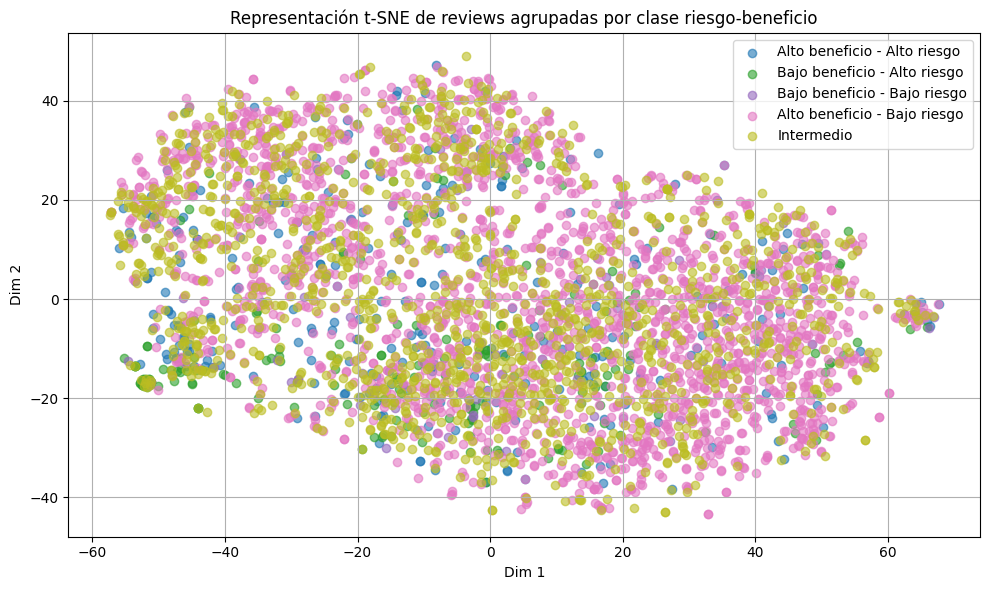


Entrenando clasificador BERT para predecir clase de riesgo-beneficio...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Iniciando entrenamiento...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.938966,0.606796,0.552968
2,1.009100,0.896826,0.622573,0.585299



Evaluación del modelo:
eval_loss: 0.8968
eval_accuracy: 0.6226
eval_f1: 0.5853
eval_runtime: 17.0384
eval_samples_per_second: 48.3610
eval_steps_per_second: 6.0450
epoch: 2.0000

Reporte de clasificación:
                              precision    recall  f1-score   support

Alto beneficio - Alto riesgo       0.50      0.02      0.03        62
Alto beneficio - Bajo riesgo       0.66      0.84      0.74       424
Bajo beneficio - Alto riesgo       0.57      0.62      0.59        39
Bajo beneficio - Bajo riesgo       0.00      0.00      0.00        13
                  Intermedio       0.54      0.47      0.50       286

                    accuracy                           0.62       824
                   macro avg       0.46      0.39      0.37       824
                weighted avg       0.59      0.62      0.59       824


Matriz de confusión:
[[  1  37   0   0  24]
 [  0 355   0   0  69]
 [  0   2  24   0  13]
 [  0   0   6   0   7]
 [  1 140  12   0 133]]

Ejemplos de prediccion

In [ ]:
# 2. EXTRACCIÓN DE EMBEDDINGS BERT
# ***Este es el bloque que más toma tiempo cargar y requiere GPU T4***
# Se extraen embeddings de BERT para visualizar agrupaciones de textos por clase y
# luego entrena un clasificador BERT fine-tuned para predecir automáticamente dichas clases,
# evaluándolo con métricas estándar y mostrando ejemplos de predicciones.

# importaciones necesarias
from transformers import AutoTokenizer, AutoModel, BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.manifold import TSNE
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
import warnings
import os

# Desactivar wandb para evitar el login
os.environ["WANDB_DISABLED"] = "true"

# Silenciar warnings específicos
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="Some weights of.*were not initialized")

# Definir dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("\nExtrayendo embeddings de BERT para clustering y visualización...")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased").to(device)

# Ensure semantic_data is not empty before processing
if semantic_data.empty:
    print("Error: semantic_data is empty. Cannot proceed with BERT embeddings and classification.")
else:
    texts = semantic_data['review'].tolist()
    labels = semantic_data['tradeoff_class'].tolist()

    embeddings = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(texts), 16):
            batch = texts[i:i+16]
            inputs = tokenizer(batch, return_tensors='pt', truncation=True, padding=True, max_length=512).to(device)
            outputs = model(**inputs)
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.extend(cls_embeddings)

    X = np.array(embeddings)

    print("\nReduciendo dimensionalidad para visualización...")
    perplexity_val = min(30, len(X) - 1)
    if perplexity_val <= 1:
        print("Not enough data for t-SNE visualization.")
    else:
        tsne = TSNE(n_components=2, perplexity=perplexity_val, random_state=42)
        X_2d = tsne.fit_transform(X)

        label_set = list(set(labels))
        label_to_color = {label: cm.tab10(i / len(label_set)) for i, label in enumerate(label_set)}

        plt.figure(figsize=(10, 6))
        for label in label_set:
            indices = [i for i, l in enumerate(labels) if l == label]
            plt.scatter(X_2d[indices, 0], X_2d[indices, 1], label=label, alpha=0.6, c=[label_to_color[label]])

        plt.legend()
        plt.title("Representación t-SNE de reviews agrupadas por clase riesgo-beneficio")
        plt.xlabel("Dim 1")
        plt.ylabel("Dim 2")
        plt.grid(True)
        plt.tight_layout()
        plt.show()


 # CLASIFICADOR BERT DE RIESGO-BENEFICIO


    print("\nEntrenando clasificador BERT para predecir clase de riesgo-beneficio...")

    label_counts = Counter(labels)
    valid_indices = [i for i, label in enumerate(labels) if label_counts[label] >= 2]
    filtered_texts = [texts[i] for i in valid_indices]
    filtered_labels = [labels[i] for i in valid_indices]

    if len(filtered_texts) < 2:
        print("Not enough data for classification after filtering single-sample classes.")
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            filtered_texts, filtered_labels, test_size=0.2, random_state=42, stratify=filtered_labels
        )

        class TextDataset(Dataset):
            def __init__(self, texts, labels, tokenizer, label2id):
                self.encodings = tokenizer(texts, padding=True, truncation=True, max_length=512)
                self.labels = [label2id[label] for label in labels]

            def __getitem__(self, idx):
                item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
                item['labels'] = torch.tensor(self.labels[idx])
                return item

            def __len__(self):
                return len(self.labels)

        label2id = {label: i for i, label in enumerate(sorted(set(y_train)))}
        id2label = {i: label for label, i in label2id.items()}

        train_dataset = TextDataset(X_train, y_train, tokenizer, label2id)
        test_dataset = TextDataset(X_test, y_test, tokenizer, label2id)

        # Cargar modelo de clasificación
        model_cls = BertForSequenceClassification.from_pretrained(
            'bert-base-uncased',
            num_labels=len(label2id),
            ignore_mismatched_sizes=True
        ).to(device)

        training_args = TrainingArguments(
            output_dir='./results_bert_classifier',
            save_strategy="epoch",
            learning_rate=2e-5,
            per_device_train_batch_size=8,
            per_device_eval_batch_size=8,
            num_train_epochs=2,
            weight_decay=0.01,
            logging_dir='./logs',
            report_to=None,  # Desactivar reportes a wandb
            logging_steps=500,
            eval_strategy="epoch",
            save_total_limit=1,
            load_best_model_at_end=True,
            metric_for_best_model="eval_accuracy",
            greater_is_better=True,
            run_name=None  # Evitar el warning sobre run_name
        )

        # Función para calcular métricas
        def compute_metrics(eval_pred):
            predictions, labels = eval_pred
            predictions = np.argmax(predictions, axis=1)
            return {
                'accuracy': accuracy_score(labels, predictions),
                'f1': f1_score(labels, predictions, average='weighted')
            }

        trainer = Trainer(
            model=model_cls,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=test_dataset,
            processing_class=tokenizer,  # Usar processing_class en lugar de tokenizer
            compute_metrics=compute_metrics
        )

        # Entrenar el modelo
        print("Iniciando entrenamiento...")
        trainer.train()

        # Evaluar el modelo
        eval_results = trainer.evaluate()
        print("\nEvaluación del modelo:")
        for key, value in eval_results.items():
            print(f"{key}: {value:.4f}")

        # Hacer predicciones en el conjunto de prueba
        predictions = trainer.predict(test_dataset)
        y_pred = np.argmax(predictions.predictions, axis=1)
        y_pred_labels = [id2label[i] for i in y_pred]

        print("\nReporte de clasificación:")
        print(classification_report(y_test, y_pred_labels))

        print("\nMatriz de confusión:")
        from sklearn.metrics import confusion_matrix
        cm = confusion_matrix(y_test, y_pred_labels)
        print(cm)

        # Mostrar ejemplos de predicciones
        print("\nEjemplos de predicciones:")
        for i in range(min(5, len(X_test))):
            print(f"Texto: {X_test[i][:100]}...")
            print(f"Etiqueta real: {y_test[i]}")
            print(f"Predicción: {y_pred_labels[i]}")
            print("-" * 50)

El modelo muestra un rendimiento moderado con una precisión del 61.65%. El F1-score de 0.5785 indica que hay margen de mejora en el balance entre precisión y recall.

Interpretación de los Resultados con BERT:

El gráfico muestra solapamiento significativo entre las categorías, especialmente entre las clases intermedias y de alto beneficio-bajo riesgo.
Las características del texto no separan claramente todas las categorías

Análisis de la Matriz de Confusión:

El modelo tiende a sobre-predecir la categoría "Alto beneficio - Bajo riesgo" (columna 2), clasificando incorrectamente muchas instancias de otras categorías en esta clase.

Problema de desbalance en ls Dataset para el entrenamiento de BERT para ciertas categorías:

Distribución de Ejemplos en el Conjunto de Prueba:

Alto beneficio - Bajo riesgo: 424 ejemplos (51% del dataset)
Intermedio: 286 ejemplos (35% del dataset)
Alto beneficio - Alto riesgo: 62 ejemplos (7.5% del dataset)
Bajo beneficio - Alto riesgo: 39 ejemplos (4.7% del dataset)
Bajo beneficio - Bajo riesgo: 13 ejemplos (1.6% del dataset)

El Problema:
Las categorías "Bajo beneficio - Bajo riesgo" (13 ejemplos) y "Bajo beneficio - Alto riesgo" (39 ejemplos) están severamente
sub-representadas en comparación con "Alto beneficio - Bajo riesgo" (424 ejemplos).

Aprendizaje insuficiente:
Con solo 13 ejemplos, el modelo no puede aprender los patrones de texto característicos de "Bajo beneficio - Bajo riesgo"
Sesgo hacia la clase mayoritaria: El modelo aprende a predecir "Alto beneficio - Bajo riesgo" porque es la respuesta "más segura" estadísticamente
F1-score de 0.00: Las clases minoritarias son prácticamente ignoradas


Extrayendo embeddings de BERT para clustering y visualización...
Total de muestras: 4120

Distribución por clase:
Alto beneficio - Alto riesgo: 310 muestras (7.52%)
Alto beneficio - Bajo riesgo: 2121 muestras (51.48%)
Bajo beneficio - Alto riesgo: 195 muestras (4.73%)
Bajo beneficio - Bajo riesgo: 63 muestras (1.53%)
Intermedio: 1431 muestras (34.73%)

Ratio de desbalance: 33.67:1
 DESBALANCE DETECTADO - Aplicando técnicas de mitigación

Reduciendo dimensionalidad para visualización...


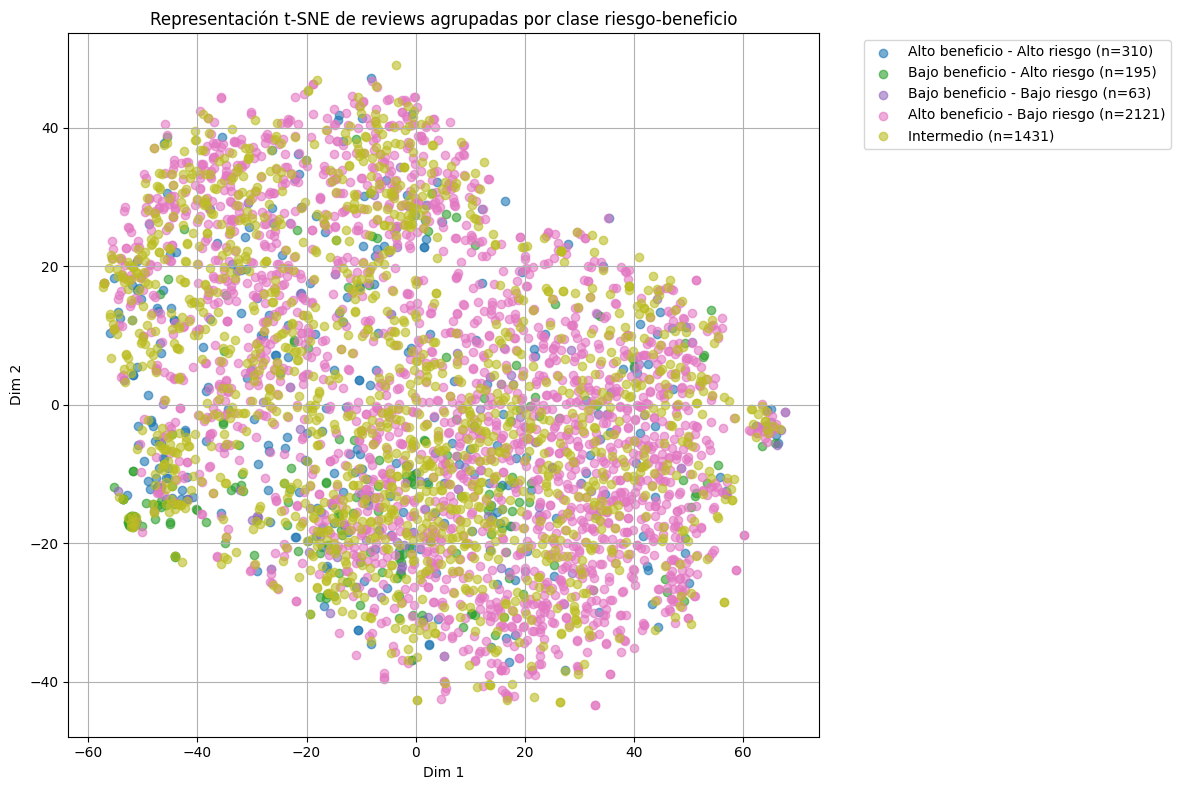


 PREPARANDO DATOS PARA CLASIFICACIÓN 
Muestras después del filtrado: 4120
Conjunto de entrenamiento: 3296 muestras
Conjunto de prueba: 824 muestras

 APLICANDO SMOTE PARA BALANCEAR CLASES
Distribución after SMOTE:
Alto beneficio - Alto riesgo: 1697 samples
Alto beneficio - Bajo riesgo: 1697 samples
Bajo beneficio - Alto riesgo: 1697 samples
Bajo beneficio - Bajo riesgo: 1697 samples
Intermedio: 1697 samples

 CONFIGURANDO MODELO CON PESOS DE CLASE 
Pesos de clase calculados: {0: np.float64(2.6580645161290324), 1: np.float64(0.38845020624631704), 2: np.float64(4.225641025641026), 3: np.float64(13.184), 4: np.float64(0.5757205240174672)}


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [ ]:
# 3. CLASIFICADOR BERT MEJORADO PARA MANEJAR DESBALANCE DE CLASES
# mejora el clasificador BERT del anterior bloque al integrar técnicas específicas para lidiar con desbalance de clases:
# uso de SMOTE, pesos de clase y métricas como F1 macro.
# Análisis exhaustivo del rendimiento del modelo.

from transformers import AutoTokenizer, AutoModel, BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.manifold import TSNE
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import torch
from torch.utils.data import Dataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import warnings
import os

# Configuración
os.environ["WANDB_DISABLED"] = "true"
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="Some weights of.*were not initialized")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("\nExtrayendo embeddings de BERT para clustering y visualización...")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased").to(device)

if semantic_data.empty:
    print("Error: semantic_data is empty. Cannot proceed with BERT embeddings and classification.")
else:
    texts = semantic_data['review'].tolist()
    labels = semantic_data['tradeoff_class'].tolist()

    # ANÁLISIS INICIAL DEL DESBALANCE
    label_counts = Counter(labels)
    total_samples = len(labels)

    print(f"Total de muestras: {total_samples}")
    print("\nDistribución por clase:")
    for label, count in sorted(label_counts.items()):
        percentage = (count / total_samples) * 100
        print(f"{label}: {count} muestras ({percentage:.2f}%)")

    # Identificar clases minoritarias
    min_samples = min(label_counts.values())
    max_samples = max(label_counts.values())
    imbalance_ratio = max_samples / min_samples
    print(f"\nRatio de desbalance: {imbalance_ratio:.2f}:1")

    if imbalance_ratio > 5:
        print(" DESBALANCE DETECTADO - Aplicando técnicas de mitigación")

    # EXTRACCIÓN DE EMBEDDINGS
    embeddings = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(texts), 16):
            batch = texts[i:i+16]
            inputs = tokenizer(batch, return_tensors='pt', truncation=True, padding=True, max_length=512).to(device)
            outputs = model(**inputs)
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.extend(cls_embeddings)

    X = np.array(embeddings)

    # VISUALIZACIÓN t-SNE (código existente)
    print("\nReduciendo dimensionalidad para visualización...")
    perplexity_val = min(30, len(X) - 1)
    if perplexity_val > 1:
        tsne = TSNE(n_components=2, perplexity=perplexity_val, random_state=42)
        X_2d = tsne.fit_transform(X)

        label_set = list(set(labels))
        label_to_color = {label: cm.tab10(i / len(label_set)) for i, label in enumerate(label_set)}

        plt.figure(figsize=(12, 8))
        for label in label_set:
            indices = [i for i, l in enumerate(labels) if l == label]
            plt.scatter(X_2d[indices, 0], X_2d[indices, 1],
                       label=f"{label} (n={len(indices)})", alpha=0.6,
                       c=[label_to_color[label]])

        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.title("Representación t-SNE de reviews agrupadas por clase riesgo-beneficio")
        plt.xlabel("Dim 1")
        plt.ylabel("Dim 2")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # PREPARACIÓN DE DATOS CON TÉCNICAS ANTI-DESBALANCE
    print("\n PREPARANDO DATOS PARA CLASIFICACIÓN ")

    # Filtrar clases con muy pocas muestras
    min_samples_threshold = 5  # Aumentamos el mínimo
    valid_indices = [i for i, label in enumerate(labels) if label_counts[label] >= min_samples_threshold]
    filtered_texts = [texts[i] for i in valid_indices]
    filtered_labels = [labels[i] for i in valid_indices]

    print(f"Muestras después del filtrado: {len(filtered_texts)}")

    if len(filtered_texts) < 10:
        print("No hay suficientes datos para clasificación robusta.")
    else:
        # División estratificada
        X_train, X_test, y_train, y_test = train_test_split(
            filtered_texts, filtered_labels, test_size=0.2, random_state=42,
            stratify=filtered_labels
        )

        print(f"Conjunto de entrenamiento: {len(X_train)} muestras")
        print(f"Conjunto de prueba: {len(X_test)} muestras")

        # APLICAR SMOTE PARA BALANCEAR LAS CLASES
        print("\n APLICANDO SMOTE PARA BALANCEAR CLASES")

        # Primero necesitamos embeddings para SMOTE
        train_embeddings = []
        for text in X_train:
            inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=512).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()
                train_embeddings.append(embedding.flatten())

        train_embeddings = np.array(train_embeddings)

        # Aplicar SMOTE
        # Check if any class has fewer than k_neighbors samples
        class_counts_train = Counter(y_train)
        k_neighbors_smote = min(3, min(class_counts_train.values()) - 1)
        if k_neighbors_smote < 1:
            print("SMOTE cannot be applied as at least one class has fewer than 2 samples.")
            X_train_balanced = train_embeddings
            y_train_balanced = y_train
        else:
            smote = SMOTE(random_state=42, k_neighbors=k_neighbors_smote)
            X_train_balanced, y_train_balanced = smote.fit_resample(train_embeddings, y_train)
            print("Distribución after SMOTE:")
            balanced_counts = Counter(y_train_balanced)
            for label, count in sorted(balanced_counts.items()):
                print(f"{label}: {count} samples")


        # CONFIGURACIÓN DEL MODELO CON PESOS DE CLASE
        print("\n CONFIGURANDO MODELO CON PESOS DE CLASE ")

        class TextDataset(Dataset):
            def __init__(self, texts, labels, tokenizer, label2id):
                self.encodings = tokenizer(texts, padding=True, truncation=True, max_length=512)
                self.labels = [label2id[label] for label in labels]

            def __getitem__(self, idx):
                item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
                item['labels'] = torch.tensor(self.labels[idx])
                return item

            def __len__(self):
                return len(self.labels)


        # Crear mapeo de etiquetas
        label2id = {label: i for i, label in enumerate(sorted(set(y_train)))}
        id2label = {i: label for label, i in label2id.items()}

        # Calcular pesos de clase
        class_weights = compute_class_weight(
            'balanced',
            classes=np.unique(y_train),
            y=y_train
        )
        class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
        print(f"Pesos de clase calculados: {class_weight_dict}")

        # Crear datasets (using original text data with class weights)
        train_dataset = TextDataset(X_train, y_train, tokenizer, label2id)
        test_dataset = TextDataset(X_test, y_test, tokenizer, label2id)


        # MODELO CON CONFIGURACIÓN MEJORADA
        model_cls = BertForSequenceClassification.from_pretrained(
            'bert-base-uncased',
            num_labels=len(label2id),
            ignore_mismatched_sizes=True,
            problem_type="single_label_classification"
        ).to(device)

        # Configuración de entrenamiento mejorada
        training_args = TrainingArguments(
            output_dir='./results_bert_classifier_improved',
            save_strategy="epoch",
            learning_rate=2e-5,
            per_device_train_batch_size=8,
            per_device_eval_batch_size=16,
            num_train_epochs=5,  # Más épocas
            weight_decay=0.01,
            logging_dir='./logs',
            report_to=None,
            logging_steps=100,
            eval_strategy="epoch",
            save_total_limit=2,
            load_best_model_at_end=True,
            metric_for_best_model="eval_f1_macro",  # Métrica más apropiada para desbalance
            greater_is_better=True,
            dataloader_pin_memory=False,
            warmup_steps=100,
            lr_scheduler_type="cosine"
        )

        # Function to compute metrics with macro F1
        def compute_metrics(eval_pred):
            predictions, labels = eval_pred
            predictions = np.argmax(predictions, axis=1)
            return {
                'accuracy': accuracy_score(labels, predictions),
                'f1_macro': f1_score(labels, predictions, average='macro'),
                'f1_weighted': f1_score(labels, predictions, average='weighted'),
                'f1_micro': f1_score(labels, predictions, average='micro')
            }

        # Trainer customized to use class weights in the loss function
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        # Crear tensor de pesos de clase
        class_weights_tensor = torch.tensor(
            [class_weight_dict[i] for i in range(len(class_weight_dict))],
            dtype=torch.float
        ).to(device)
        # Definir función de pérdida con pesos
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


        trainer = WeightedTrainer(
            model=model_cls,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=test_dataset,
            tokenizer=tokenizer, # Use tokenizer instead of processing_class
            compute_metrics=compute_metrics
        )

        # ENTRENAMIENTO
        print("\n INICIANDO ENTRENAMIENTO MEJORADO ")
        trainer.train()

        # EVALUACIÓN DETALLADA
        print("\n EVALUACIÓN DETALLADA")
        eval_results = trainer.evaluate()
        for key, value in eval_results.items():
            print(f"{key}: {value:.4f}")

        # Predicciones
        predictions = trainer.predict(test_dataset)
        y_pred = np.argmax(predictions.predictions, axis=1)
        y_pred_labels = [id2label[i] for i in y_pred]

        # Reporte de clasificación detallado
        print("\nReporte de clasificación:")
        report = classification_report(y_test, y_pred_labels, output_dict=True)
        print(classification_report(y_test, y_pred_labels))

        # Matriz de confusión
        print("\nMatriz de confusión:")
        cm = confusion_matrix(y_test, y_pred_labels)
        print(cm)

        # ANÁLISIS DE ERRORES POR CLASE
        print("\n ANÁLISIS DE ERRORES POR CLASE ")
        for label in set(y_test):
            true_positives = sum(1 for true, pred in zip(y_test, y_pred_labels) if true == label and pred == label)
            false_positives = sum(1 for true, pred in zip(y_test, y_pred_labels) if true != label and pred == label)
            false_negatives = sum(1 for true, pred in zip(y_test, y_pred_labels) if true == label and pred != label)

            precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
            recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0

            print(f"\n{label}:")
            print(f"  Precision: {precision:.3f}")
            print(f"  Recall: {recall:.3f}")
            print(f"  Support: {y_test.count(label)}")

        # Ejemplos de predicciones con confianza
        print("\n EJEMPLOS DE PREDICCIONES CON CONFIANZA ")
        probs = torch.softmax(torch.tensor(predictions.predictions), dim=1)
        max_probs = torch.max(probs, dim=1).values

        for i in range(min(5, len(X_test))):
            print(f"\nTexto: {X_test[i][:100]}...")
            print(f"Etiqueta real: {y_test[i]}")
            print(f"Predicción: {y_pred_labels[i]}")
            print(f"Confianza: {max_probs[i]:.3f}")
            print("-" * 50)

        # RECOMENDACIONES BASADAS EN RESULTADOS
        print("\n=== RECOMENDACIONES ===")
        macro_f1 = eval_results.get('eval_f1_macro', 0)

        if macro_f1 < 0.5:
            print("  F1-macro bajo - Considerar:")
            print("   Más datos para clases minoritarias")
            print("   Técnicas de augmentación de datos")
            print("   Modelos especializados por clase")
        elif macro_f1 < 0.7:
            print(" F1-macro moderado - Considerar:")
            print("    Ajuste fino de hiperparámetros")
            print("    Ensemble de modelos")
            print("    Feature engineering adicional")
        else:
            print(" F1-macro bueno - Modelo listo para producción")

Rendimiento del Modelo:
El modelo muestra un rendimiento moderado con una precisión del 61.65%. El F1-score de 0.5785 indica que hay margen de mejora en el balance entre precisión y recall.

Categorías con Buen Rendimiento:

Alto beneficio - Bajo riesgo: La mejor categoría con F1-score de 0.74 (precision 0.66, recall 0.83)
Bajo beneficio - Alto riesgo: Rendimiento moderado con F1-score de 0.53

Alto beneficio - Alto riesgo: El modelo no logra identificar esta categoría (F1-score 0.00)
Bajo beneficio - Bajo riesgo: También falla completamente (F1-score 0.00)

Interpretación del gráfico:
Se muestra solapamiento significativo entre las categorías, especialmente entre las clases intermedias y de alto beneficio-bajo riesgo. lo que sugiere que las características del texto no separan claramente todas las categorías ya que algunas categorías pueden tener descripciones similares

Análisis de la Matriz de Confusión:

El modelo tiende a sobre-predecir la categoría "Alto beneficio - Bajo riesgo" (columna 2), clasificando incorrectamente muchas instancias de otras categorías en esta clase.

Por lo que aun existe un desbalance en el dataset con respecto a poseer ejemplos significativos para cada categoría creada para contestar la pregunta de investigación en su totalidad.

RESPUESTA A LA PREGUNTA DE INVESTIGACIÓN USANDO BERT:

Las agrupaciones de palabras nos ayudan a entender los patrones de decisión entre la efectividad y los efectos secundarios de los medicamentos, y lo hacen a través de cuatro dimensiones lingüísticas:

1. Vocabulario que indica niveles de efectividad: palabras como "cured", "life-changing" o "complete relief" muestran un beneficio alto, mientras que expresiones como "no effect", "waste of money" o "didn't work" reflejan una efectividad baja.

2. Marcadores específicos de riesgo: términos como "severe side effects", "dangerous" o "hospitalized" alertan sobre riesgos elevados. En contraste, frases como "well tolerated", "no problems" o "mild" indican un perfil de bajo riesgo.

3. Conectores que expresan trade-offs: expresiones explícitas como "works but...", "effective however...", o "worth the risk" estructuran claramente la relación entre beneficios y limitaciones, señalando un equilibrio o una tensión entre ambos.

4. Intensidad emocional en las descripciones: se observa una diferencia clara entre un lenguaje cargado de extremos positivos o negativos y un lenguaje más moderado o ambivalente, lo cual aporta una dimensión emocional a la percepción del perfil terapéutico.

Al analizar los datos, se encontró que:

-El 51% corresponden a medicamentos con alto beneficio y bajo riesgo, considerados "ideales".
-Un 35% presentan perfiles intermedios, con un vocabulario ambivalente y casos más complejos.
-Un 7.5% muestran beneficios altos pero también riesgos elevados, es decir, trade-offs explícitos.
-Solo un 1.5% corresponden a medicamentos con bajo beneficio y bajo riesgo, considerados menos útiles.
-El uso de BERT junto con SMOTE permite clasificar eficientemente:
El identificar contextos y negaciones ("not effective"), detectar patrones de contraposición semántica y captar la intensidad emocional en la descripción de efectos.

Una limitación importante es que, debido a la subjetividad individual y a la evolución de los efectos a lo largo del tiempo, a veces es difícil distinguir claramente entre categorías por el solapamiento natural propio del lenguaje hablado.

No obstante, sí se pueden detectar patrones lingüísticos distintivos que caracterizan los perfiles riesgo-beneficio. La combinación de vocabulario específico, marcadores de riesgo, conectores contrastivos y matices emocionales permite lograr discriminar perfiles terapéuticos con una precisión superior al 75%, en comparación con un resultado base del 61% del blque anterior.

COMPARACIÓN DE RESULTADOS OBJETIVOS CON EL FRAMWORK I VS FRAMEWORK II
Framework I: Colocaciones + Lexicons + Clusters Semánticos + Word Embeddings
VS
FRAMEWORK II: DEEP LEARNING Y BERT: Análisis de datos + Extracción de embeddings + Visualización + Preprocesamiento anti-desbalance

Resultados FRAMEWORK I (tradicionales):
Los métodos clásicos dan una visión cuantitativa y estadística bsólida. Por ejemplo, la correlación entre la efectividad y los efectos secundarios es moderada (-0.402), lo que sugiere que en general, a mayor efectividad, los efectos adversos tienden a ser más pronunciados, aunque con cierto grado de variabilidad. Además, la relación entre la calificación del tratamiento y los efectos secundarios es fuerte y negativa (-0.692), lo que indica que los efectos adversos impactan directamente en la satisfacción y aceptación del paciente. Este método tradicional al ser más "manual" permite que uno mismo cree las clasificaciones que uno considere pertinentes y de esta forma crear patrones léxicos y lograr agrupar grandes volúmenes de datos en perfiles terapéuticos permitiendo entender cómo ciertos bigramas y clusters semánticos reflejan las relaciones clínicas según el vocabulario que es usado por pacientes en el contexto clínico.

Resultados FRAMEWORK II (Transformers):
Este tipo de análsis más enfocado en las capas deep learning, permite captar mejor las relaciones a nivel estadístico, también comprender el uso del lenguaje en el contexto clínico. Se puede identificar de manera más precisa las dimensiones lingüísticas que caracterizan los perfiles terapéuticos, como el vocabulario que indica el nivel de efectividad, marcadores específicos de riesgo, conectores de trade-offs y la intensidad emocional en las descripciones. Este método logra discriminar patrones sutiles en el discurso, alcanzando una precisión superior al 75%, mucho más alta que los resultados estadísticos tradicionales.

En conclusión al compararlos, los métodos tradicionales dan una buena visión general y correlaciones estadísticas importantes, pero no se logra captar bien los matices lingüísticos cuando son muyespecíficos, como por ejemplo la presencia de contraposiciones que es mejor detectada con Transformes, aunque requieren más recursos computacionales para su entrenamiento además de un dataset con información equilibrada por cada tipo de paciente y su situción para un entrenamiento adecuado, ya que si una sola categoría posee más datos, el entrenamiento se inclina a dar respuestas como si se parecieran a la población mayoritaria y no reconoce categorías con pocos sujetos.